<div class="alert alert-block alert-info">
<center><strong> Predicting Urban vs. Rural Household Classification using Supervised Machine Learning </strong></center>
</div>

<hr/>
<center> A major course output (MCO) in completing 20% of final grade in Advanced Intelligent Systems (STINTSY) </center> 

Term 2 A.Y. 2025-2026
<br/>
**Group #2 CSINTSY Survivors (Section S18)**

| Member Name | Contributions |
| ----- | -----  |
| Chavez, Allen Visagar | text  |
| Llanes, Andre Gabriel De Ocampo  | text  |
| Rojo, Von Matthew De Guzman *(leader)* | text |
| Tan, Jeremy James Teves | text |

Professor: Antioquia, Arren Matthew Capuchino

**Project Objective:** The primary objective of this project is to develop and evaluate supervised machine learning models capable of predicting whether a family resides in an Urban or Rural area (URB).
<br/><br/>
This project utilizes a comprehensive set of socioeconomic and structural features from the Family Income and Expenditure Survey (FIES) dataset, including:
* **Housing Characteristics:** Building type, roof material, wall material, toilet facilities, electricity access, and main water source.
* **Financial Indicators:** Total income, total expenditures, food and non-food expenses, and rent values (actual and imputed).
* **Asset Ownership:** Quantities of owned assets such as cars, televisions, personal computers, air conditioners, and other household appliances.
<br/><br/>

**Methodology:** As part of the STINTSY Major Course Output (MCO), we will perform end-to-end machine learning pipeline development, starting with Data Preparation and Exploratory Data Analysis (EDA). Ultimately, we will implement and compare the performance of at least three supervised machine learning models (two classical machine learning models and one neural network) to determine the most effective approach for this classification task.
<hr/>

In [61]:
## Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np # for importing datasets
import math
import pandas as pd
import seaborn as sns
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

%load_ext autoreload
%autoreload 2
from MCO_functions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **[1]** Data Preparation
**Dataset Name:** Family Income and Expenditure Survey 2012 Vol 1
<br/>
**Accessed from:** [click this link](https://psada.psa.gov.ph/catalog/38/data-dictionary/F2?file_name=fies2012_v1)

In [2]:
csv_path = 'feis_dataset/FIES PUF 2012 Vol.1.CSV'
csvdict_path = 'feis_dataset/fies_2012_v1_metadata(dictionary)'
fies_original_df = pd.read_csv(csv_path)

fies_original_df

,W_REGN,W_OID,W_SHSN,W_HCN,URB,RSTR,PSU,BWEIGHT,RFACT,FSIZE,...,PC_QTY,OVEN_QTY,MOTOR_BANCA_QTY,MOTORCYCLE_QTY,POP_ADJ,PCINC,NATPC,NATDC,REGDC,REGPC
0,14,101001000,2,25,2,21100,415052,138.25,200.6576,3.0,...,01,01,,,0.946172,108417.00,9,8,8,9
1,14,101001000,3,43,2,21100,415052,138.25,200.6576,12.5,...,,01,,01,0.946172,30631.60,5,9,9,4
2,14,101001000,4,62,2,21100,415052,138.25,200.6576,2.0,...,,01,,,0.946172,86992.50,9,6,6,8
3,14,101001000,5,79,2,21100,415052,138.25,200.6576,4.0,...,,01,,,0.946172,43325.75,6,6,6,6
4,14,101001000,10,165,2,21100,415052,138.25,200.6576,5.0,...,,,,01,0.946172,37481.80,6,6,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40166,12,9804029001,18,568,1,22000,114062,271.25,963.2264,5.0,...,00,00,00,00,0.902863,30101.60,5,5,7,7
40167,12,9804035000,1,25,2,22000,414067,271.25,588.6253,9.0,...,00,01,00,00,0.902863,14368.89,1,5,7,3
40168,12,9804035000,2,51,2,22000,414067,271.25,588.6253,6.0,...,00,00,00,00,0.902863,19137.33,3,4,6,4
40169,12,9804035000,3,75,2,22000,414067,271.25,588.6253,5.0,...,00,01,00,00,0.902863,30985.00,5,6,7,7


Use only selected features to lessen size

In [3]:
selected_features = [
    'URB', # Target Variable
    'W_REGN', 'BLDG_TYPE', 'ROOF', 'WALLS', 'TOILET', 'ELECTRIC', 'WATER',
    'NET_RECEIPT', 'REGFT', 'EAINC', 'TOINC', 'T_FOOD_HOME', 'T_FOOD', 
    'T_CLOTH', 'T_HEALTH', 'T_HOUSING_WATER', 'T_RENTVAL', 'T_IMPUTED_RENT', 
    'T_COMMUNICATION', 'T_BREAD', 'T_MEAT', 'T_FISH', 'T_MILK', 'T_OIL', 'T_FRUIT', 
    'T_VEG', 'T_SUGAR', 'T_FOOD_NEC', 'T_COFFEE', 'T_MINERAL', 'T_NFOOD', 
    'T_TOTEX', 'T_TOTDIS', 'CAR_QTY', 'MOTORCYCLE_QTY', 'PC_QTY', 
    'LANDLINE_QTY', 'CELLPHONE_QTY', 'TV_QTY', 'RADIO_QTY', 'AIRCON_QTY', 
    'WASH_QTY', 'REF_QTY'
]

fies_subset_df = fies_original_df[selected_features].copy()
fies_subset_df

,URB,W_REGN,BLDG_TYPE,ROOF,WALLS,TOILET,ELECTRIC,WATER,NET_RECEIPT,REGFT,...,CAR_QTY,MOTORCYCLE_QTY,PC_QTY,LANDLINE_QTY,CELLPHONE_QTY,TV_QTY,RADIO_QTY,AIRCON_QTY,WASH_QTY,REF_QTY
0,2,14,1,1,1,1,1,1,4385,76666,...,,,01,,02,01,01,,01,01
1,2,14,1,5,5,3,1,1,1350,369,...,,01,,,03,01,01,,,
2,2,14,2,1,1,1,1,1,1625,14830,...,01,,,,01,01,01,01,,01
3,2,14,1,1,1,1,1,6,7649,29394,...,,,,,02,01,01,,02,01
4,2,14,1,1,1,1,1,1,7359,130,...,,01,,,01,01,01,,01,01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40166,1,12,1,1,1,1,1,1,0,140,...,00,00,00,00,02,01,01,00,00,00
40167,2,12,1,1,1,0,1,2,0,620,...,00,00,00,00,01,01,00,00,00,00
40168,2,12,1,2,2,0,1,2,1170,540,...,00,00,00,00,01,01,01,00,00,00
40169,2,12,1,1,1,2,1,2,1664,0,...,00,00,00,00,02,01,01,00,00,00


Some data cleaning... puro 01 at 00 yung PC_QTY and others.

In [4]:
qty_columns = [
    'CAR_QTY', 'MOTORCYCLE_QTY', 'PC_QTY', 'LANDLINE_QTY', 
    'CELLPHONE_QTY', 'TV_QTY', 'RADIO_QTY', 'AIRCON_QTY', 
    'WASH_QTY', 'REF_QTY'
]

# Clean and convert the columns
for col in qty_columns:
    # Convert to string, strip whitespace, and replace empty strings with '0'
    fies_subset_df[col] = fies_subset_df[col].astype(str).str.strip().replace('', '0')
    
    # Convert the column to numeric. Any weird unparseable values become NaN (errors='coerce')
    fies_subset_df[col] = pd.to_numeric(fies_subset_df[col], errors='coerce')
    
    # Fill any remaining NaNs with 0, then cast the whole column to integer
    fies_subset_df[col] = fies_subset_df[col].fillna(0).astype(int)

fies_subset_df

,URB,W_REGN,BLDG_TYPE,ROOF,WALLS,TOILET,ELECTRIC,WATER,NET_RECEIPT,REGFT,...,CAR_QTY,MOTORCYCLE_QTY,PC_QTY,LANDLINE_QTY,CELLPHONE_QTY,TV_QTY,RADIO_QTY,AIRCON_QTY,WASH_QTY,REF_QTY
0,2,14,1,1,1,1,1,1,4385,76666,...,0,0,1,0,2,1,1,0,1,1
1,2,14,1,5,5,3,1,1,1350,369,...,0,1,0,0,3,1,1,0,0,0
2,2,14,2,1,1,1,1,1,1625,14830,...,1,0,0,0,1,1,1,1,0,1
3,2,14,1,1,1,1,1,6,7649,29394,...,0,0,0,0,2,1,1,0,2,1
4,2,14,1,1,1,1,1,1,7359,130,...,0,1,0,0,1,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40166,1,12,1,1,1,1,1,1,0,140,...,0,0,0,0,2,1,1,0,0,0
40167,2,12,1,1,1,0,1,2,0,620,...,0,0,0,0,1,1,0,0,0,0
40168,2,12,1,2,2,0,1,2,1170,540,...,0,0,0,0,1,1,1,0,0,0
40169,2,12,1,1,1,2,1,2,1664,0,...,0,0,0,0,2,1,1,0,0,0


check for null values or whitespaces

In [5]:
# check if there is any null values or whitespaces
ws_or_na_df = fies_subset_df.replace(r'^\s*$', pd.NA, regex=True)
ws_or_na_ctr = ws_or_na_df.isna().sum()

print("Whitespaces or null value counts: ")
print(ws_or_na_ctr.to_string())

Whitespaces or null value counts: 
URB                0
W_REGN             0
BLDG_TYPE          0
ROOF               0
WALLS              0
TOILET             0
ELECTRIC           0
WATER              0
NET_RECEIPT        0
REGFT              0
EAINC              0
TOINC              0
T_FOOD_HOME        0
T_FOOD             0
T_CLOTH            0
T_HEALTH           0
T_HOUSING_WATER    0
T_RENTVAL          0
T_IMPUTED_RENT     0
T_COMMUNICATION    0
T_BREAD            0
T_MEAT             0
T_FISH             0
T_MILK             0
T_OIL              0
T_FRUIT            0
T_VEG              0
T_SUGAR            0
T_FOOD_NEC         0
T_COFFEE           0
T_MINERAL          0
T_NFOOD            0
T_TOTEX            0
T_TOTDIS           0
CAR_QTY            0
MOTORCYCLE_QTY     0
PC_QTY             0
LANDLINE_QTY       0
CELLPHONE_QTY      0
TV_QTY             0
RADIO_QTY          0
AIRCON_QTY         0
WASH_QTY           0
REF_QTY            0


check for any duplicates

In [6]:
# check if there are any duplicates
dupes = fies_subset_df.duplicated().sum()

if (dupes <= 0):
  print('There are no duplicates')
else:
  print('There are', dupes, 'duplicates')

There are no duplicates


# **[2]** Exploratory Data Analysis (EDA)
This phase allows exploration of datasets and check any anomalies present.
1. Basic Dataset Information
2. Urban and Rural Comparative Statistics

# **[2.1]** Basic Dataset Information
- column statistics

In [7]:
# summary for all columns
description = fies_subset_df.describe().T
print(description.to_string())

                   count           mean            std     min      25%       50%       75%         max
URB              40171.0       1.617311       0.486049     1.0      1.0       2.0       2.0         2.0
W_REGN           40171.0      13.019890      11.995555     1.0      6.0      10.0      14.0        42.0
BLDG_TYPE        40171.0       1.087949       0.388863     1.0      1.0       1.0       1.0         6.0
ROOF             40171.0       1.377760       0.894712     1.0      1.0       1.0       1.0         7.0
WALLS            40171.0       1.641607       1.125698     1.0      1.0       1.0       2.0         7.0
TOILET           40171.0       1.718130       1.539145     0.0      1.0       1.0       2.0         7.0
ELECTRIC         40171.0       1.131563       0.338019     1.0      1.0       1.0       1.0         2.0
WATER            40171.0       3.186030       2.405758     1.0      1.0       3.0       4.0        12.0
NET_RECEIPT      40171.0    2924.002713    4302.292834     0.0  

# **[2.2]** Urban and Rural Comparative Statistics
- income and expenditure distribution
- regional distribution
- household composition

 ### **1.) Income and Expenditure Distribution** 

In [8]:
columns = fies_subset_df.columns

T_columns = [col for col in columns if col.startswith("T_")] # categories

income_prefixes = ("NET_", "REGFT", "EAINC", "TOINC")
NET_columns = [col for col in columns if col.upper().startswith(income_prefixes)] # categories


rural_df =  fies_subset_df[fies_subset_df["URB"] == 2]
urban_df = fies_subset_df[fies_subset_df["URB"] == 1]

# Monthly expenses categories
rural_T_df = rural_df[T_columns]
urban_T_df = urban_df[T_columns]

rural_T_mean_sr = rural_T_df.mean()
urban_T_mean_sr = urban_T_df.mean()

# Income and receipts categories
rural_NET_df = rural_df[NET_columns]
urban_NET_df = urban_df[NET_columns]

rural_NET_mean_sr = rural_NET_df.mean()
urban_NET_mean_sr = urban_NET_df.mean()

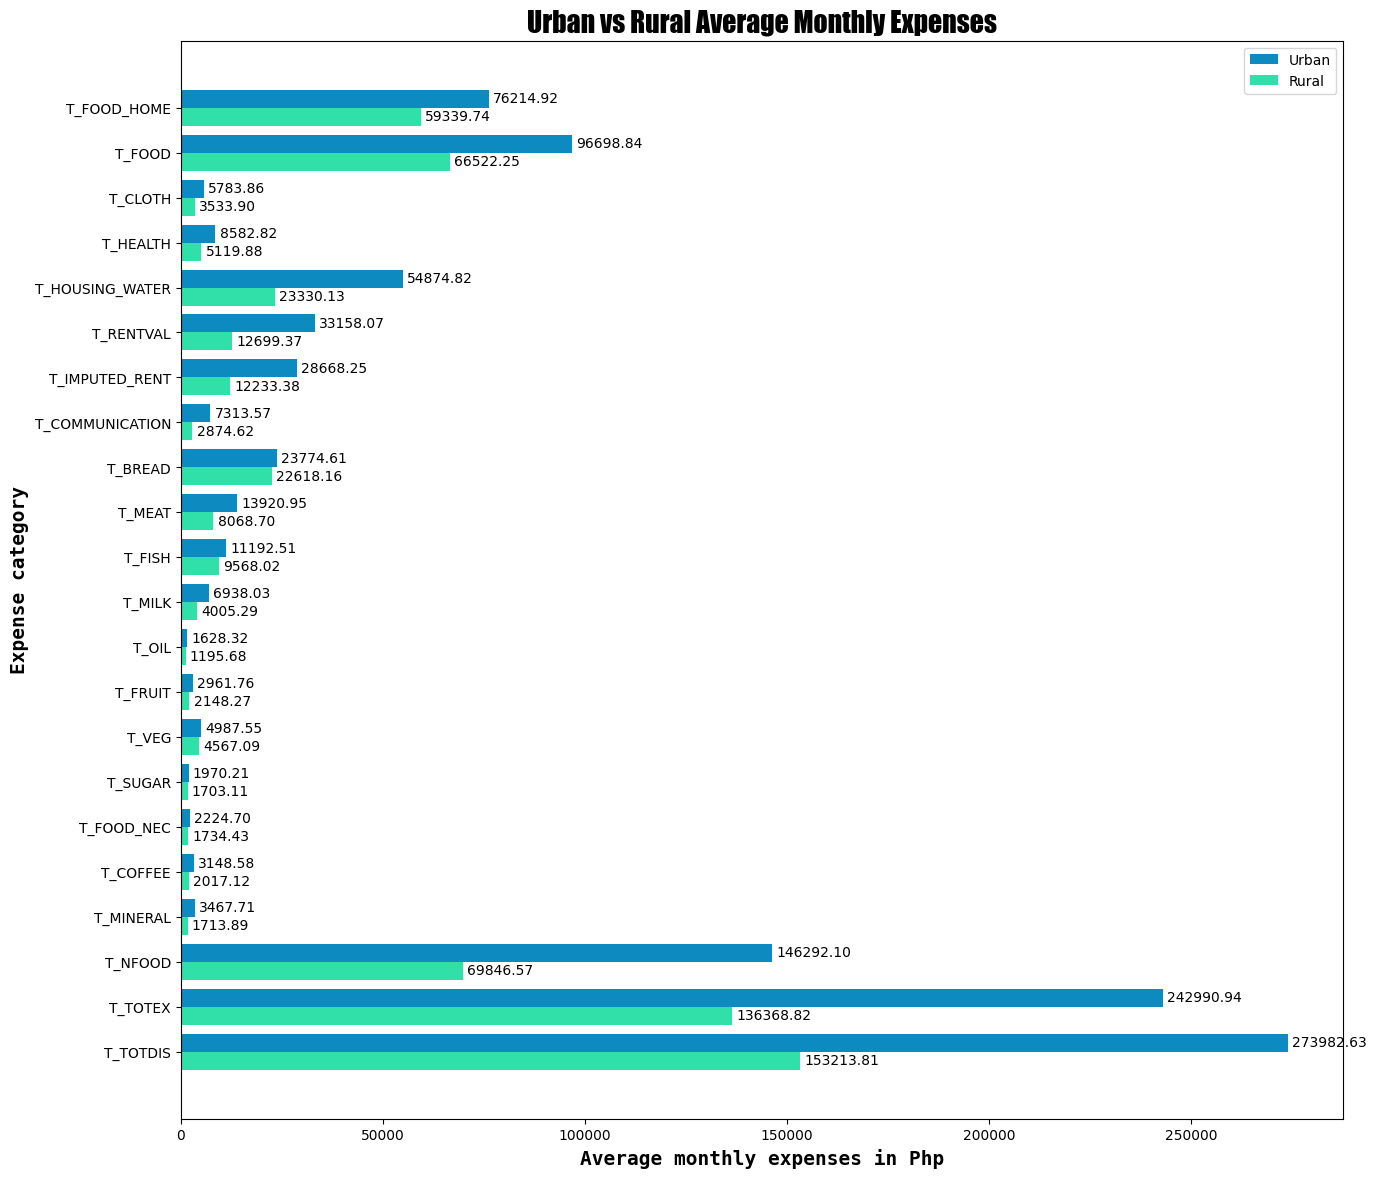

In [9]:
# Compare the average monthly expenses of urban and rural households
compareChart(
    mode="T", # expense
    n=len(T_columns), 
    cat=T_columns, 
    figwidth=15, 
    figheight=14, 
    urban_columns=urban_T_mean_sr.values, 
    rural_columns=rural_T_mean_sr.values, 
    title="Urban vs Rural Average Monthly Expenses"
)

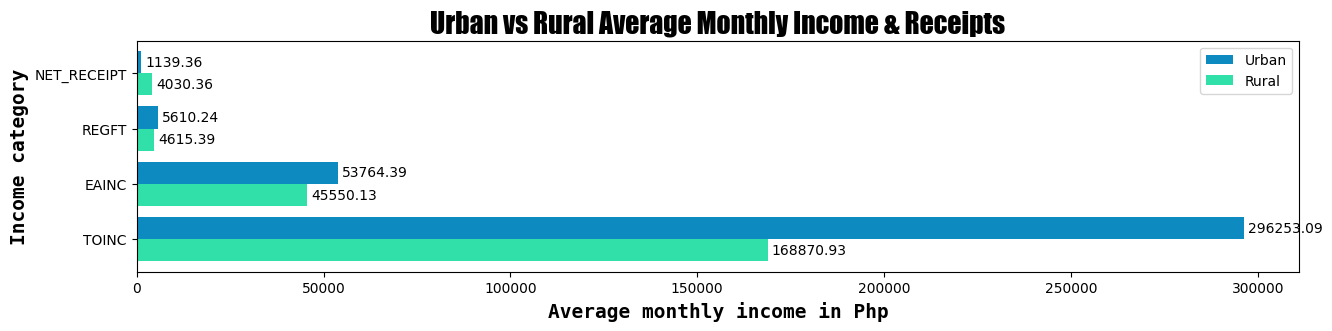

In [10]:
# Compare the average monthly income and receipts of urban and rural households
compareChart(
    mode="N", # income
    n=len(NET_columns), 
    cat=NET_columns, 
    figwidth=15, 
    figheight=3,
    urban_columns=urban_NET_mean_sr.values, 
    rural_columns=rural_NET_mean_sr.values, 
    title="Urban vs Rural Average Monthly Income & Receipts"
)

 ### **2.) Regional Distribution** 

In [11]:

# ── Label mappings ────────────────────────────────────────────────────────────
REGION_LABELS = {
    1:  "Region I\n(Ilocos)",         2:  "Region II\n(Cagayan Valley)",
    3:  "Region III\n(C. Luzon)",     5:  "Region V\n(Bicol)",
    6:  "Region VI\n(W. Visayas)",    7:  "Region VII\n(C. Visayas)",
    8:  "Region VIII\n(E. Visayas)",  9:  "Region IX\n(Zamboanga)",
    10: "Region X\n(N. Mindanao)",    11: "Region XI\n(Davao)",
    12: "Region XII\n(SOCCSKSARGEN)", 13: "NCR",
    14: "CAR",                        15: "ARMM",
    16: "CARAGA",                     41: "Region IVA\n(CALABARZON)",
    42: "Region IVB\n(MIMAROPA)",
}
BLDG_LABELS  = {1:"Single House", 2:"Duplex", 3:"Multi-unit", 4:"Commercial/Industrial", 5:"Makeshift", 6:"Other"}
ROOF_LABELS  = {1:"Strong", 2:"Light", 3:"Salvaged/Makeshift", 4:"Mixed→Strong", 5:"Mixed→Light", 6:"Mixed→Salvaged", 7:"N/A"}
WALLS_LABELS = {1:"Strong", 2:"Light", 3:"Salvaged/Makeshift", 4:"Mixed→Strong", 5:"Mixed→Light", 6:"Mixed→Salvaged", 7:"N/A"}
TOILET_LABELS= {0:"None", 1:"Water-sealed (own)", 2:"Water-sealed (shared)", 3:"WS Other (own)", 4:"WS Other (shared)", 5:"Closed Pit", 6:"Open Pit", 7:"Others"}
ELECTRIC_LABELS = {1:"Yes", 2:"No"}
WATER_LABELS = {
    1:"Comm. Faucet (own)", 2:"Comm. Faucet (shared)", 3:"Deep Well (own)",
    4:"Deep Well (shared)", 5:"Shallow Well", 6:"Dug Well",
    7:"Protected Spring", 8:"Unprotected Spring", 9:"Lake/River/Rain",
    10:"Peddler", 11:"Bottled", 12:"Others"
}

urban_c, rural_c = "#0d8ac0", "#30e0a8"

# Apply readable labels to a working copy
fies_subset_df_labeled = fies_subset_df.copy()
fies_subset_df_labeled["URB_LABEL"]   = fies_subset_df_labeled["URB"].map({1:"Urban", 2:"Rural"})
fies_subset_df_labeled["REGION_LABEL"]= fies_subset_df_labeled["W_REGN"].map(REGION_LABELS)


print("Label mappings ready.")


Label mappings ready.


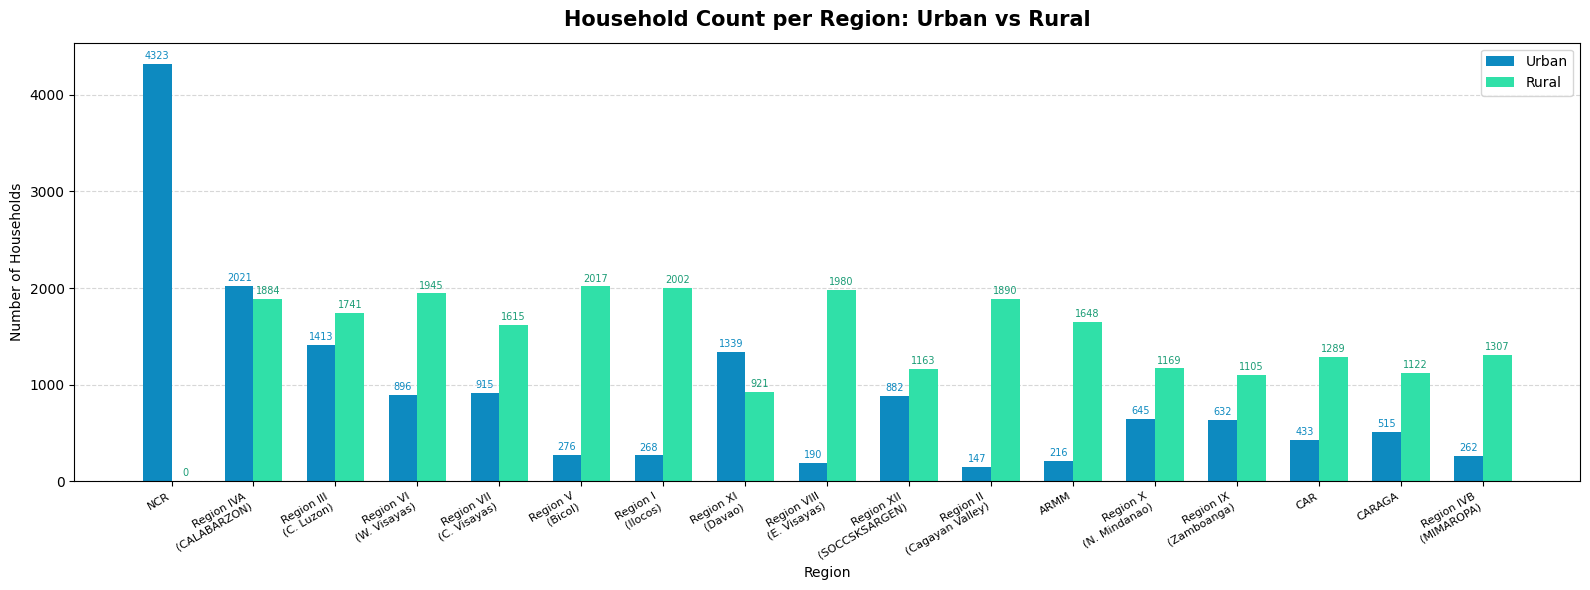

In [12]:
# ── Regional counts: Urban vs Rural ─────────────────────────────────────────
region_urb = (
    fies_subset_df_labeled
    .groupby(["REGION_LABEL", "URB_LABEL"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both columns exist
for col in ["Urban", "Rural"]:
    if col not in region_urb.columns:
        region_urb[col] = 0

region_urb["Total"] = region_urb["Urban"] + region_urb["Rural"]
region_urb = region_urb.sort_values("Total", ascending=False)

# ── Plot 1: Grouped bar — raw counts ────────────────────────────────────────
regions = region_urb.index.tolist()
x       = np.arange(len(regions))
bar_w   = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
b_u = ax.bar(x - bar_w/2, region_urb["Urban"], bar_w, label="Urban", color=urban_c)
b_r = ax.bar(x + bar_w/2, region_urb["Rural"],  bar_w, label="Rural",  color=rural_c)

for bar in b_u:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=7, color=urban_c)
for bar in b_r:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=7, color="#1a9c75")

ax.set_title("Household Count per Region: Urban vs Rural", fontsize=15, fontweight="bold", pad=12)
ax.set_xticks(x); ax.set_xticklabels(regions, fontsize=8, rotation=30, ha="right")
ax.set_xlabel("Region"); ax.set_ylabel("Number of Households")
ax.yaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)
ax.legend()
plt.tight_layout(); plt.show()


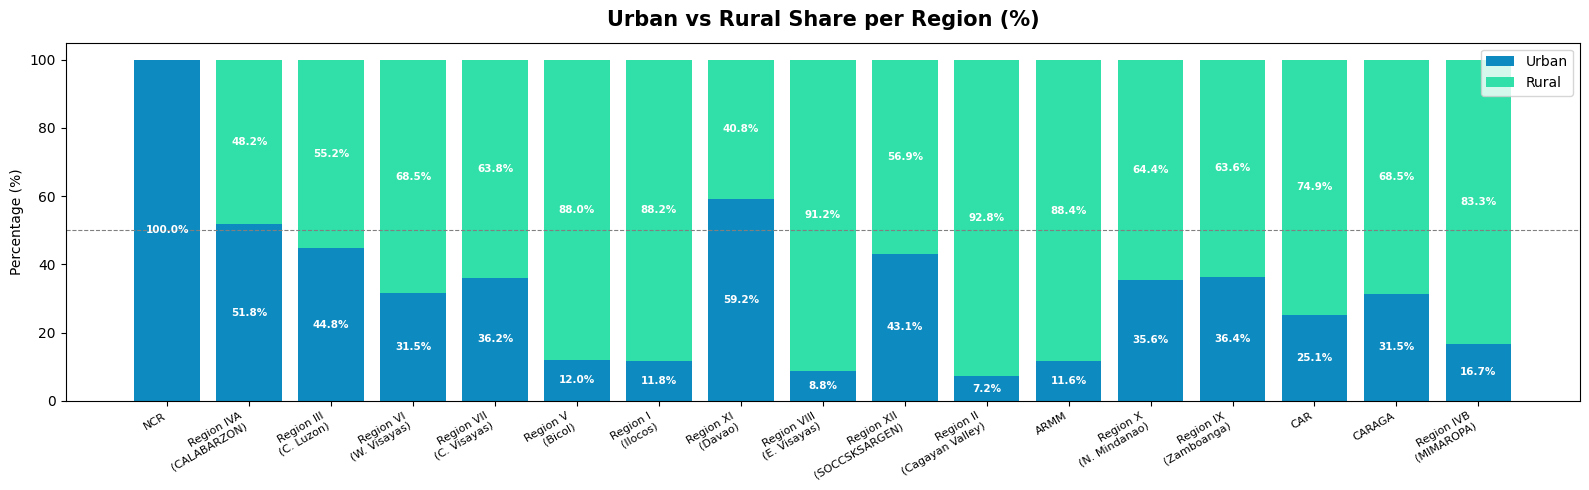


Region                             Urban   Rural   Total  %Urban  %Rural
────────────────────────────────────────────────────────────────────
NCR                                 4323       0    4323   100.0     0.0
Region IVA (CALABARZON)             2021    1884    3905    51.8    48.2
Region III (C. Luzon)               1413    1741    3154    44.8    55.2
Region VI (W. Visayas)               896    1945    2841    31.5    68.5
Region VII (C. Visayas)              915    1615    2530    36.2    63.8
Region V (Bicol)                     276    2017    2293    12.0    88.0
Region I (Ilocos)                    268    2002    2270    11.8    88.2
Region XI (Davao)                   1339     921    2260    59.2    40.8
Region VIII (E. Visayas)             190    1980    2170     8.8    91.2
Region XII (SOCCSKSARGEN)            882    1163    2045    43.1    56.9
Region II (Cagayan Valley)           147    1890    2037     7.2    92.8
ARMM                                 216    1648    18

In [13]:

# Plot 2: Stacked 100% bar — Urban/Rural proportion per region 
region_pct = region_urb[["Urban","Rural"]].div(region_urb["Total"], axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(regions, region_pct["Urban"], label="Urban", color=urban_c)
ax.bar(regions, region_pct["Rural"], bottom=region_pct["Urban"], label="Rural", color=rural_c)

for i, r in enumerate(regions):
    u, ru = region_pct.loc[r,"Urban"], region_pct.loc[r,"Rural"]
    if u  >= 6: ax.text(i, u/2,    f"{u:.1f}%",  ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
    if ru >= 6: ax.text(i, u+ru/2, f"{ru:.1f}%", ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")

ax.axhline(50, linestyle="--", color="gray", linewidth=0.8)
ax.set_title("Urban vs Rural Share per Region (%)", fontsize=15, fontweight="bold", pad=12)
ax.set_xticks(range(len(regions))); ax.set_xticklabels(regions, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("Percentage (%)"); ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout(); plt.show()

# Summary table
stats = region_urb.copy()
stats["% Urban"] = (stats["Urban"] / stats["Total"] * 100).round(1)
stats["% Rural"] = (stats["Rural"] / stats["Total"] * 100).round(1)
print(f"\n{'Region':<32} {'Urban':>7} {'Rural':>7} {'Total':>7} {'%Urban':>7} {'%Rural':>7}")
print("─" * 68)
for region, row in stats.iterrows():
    print(f"{region.replace(chr(10),' '):<32} {int(row.Urban):>7} {int(row.Rural):>7} {int(row.Total):>7} {row['% Urban']:>7.1f} {row['% Rural']:>7.1f}")
print("─" * 68)
tot = stats[["Urban","Rural","Total"]].sum()
print(f"{'TOTAL':<32} {int(tot.Urban):>7} {int(tot.Rural):>7} {int(tot.Total):>7} {tot.Urban/tot.Total*100:>7.1f} {tot.Rural/tot.Total*100:>7.1f}")


 ### **3.) Household Composition** 

#### Structural Feature Distributions: Urban vs Rural
How building type, roof material, and wall material differ between urban and rural households.

Let's take a look at the overall house composition distribution across all records combined with the features `BLDG_TYPE`, `ROOF`, `WALLS`, `TOILET`, `ELECTRIC`, and `WATER`

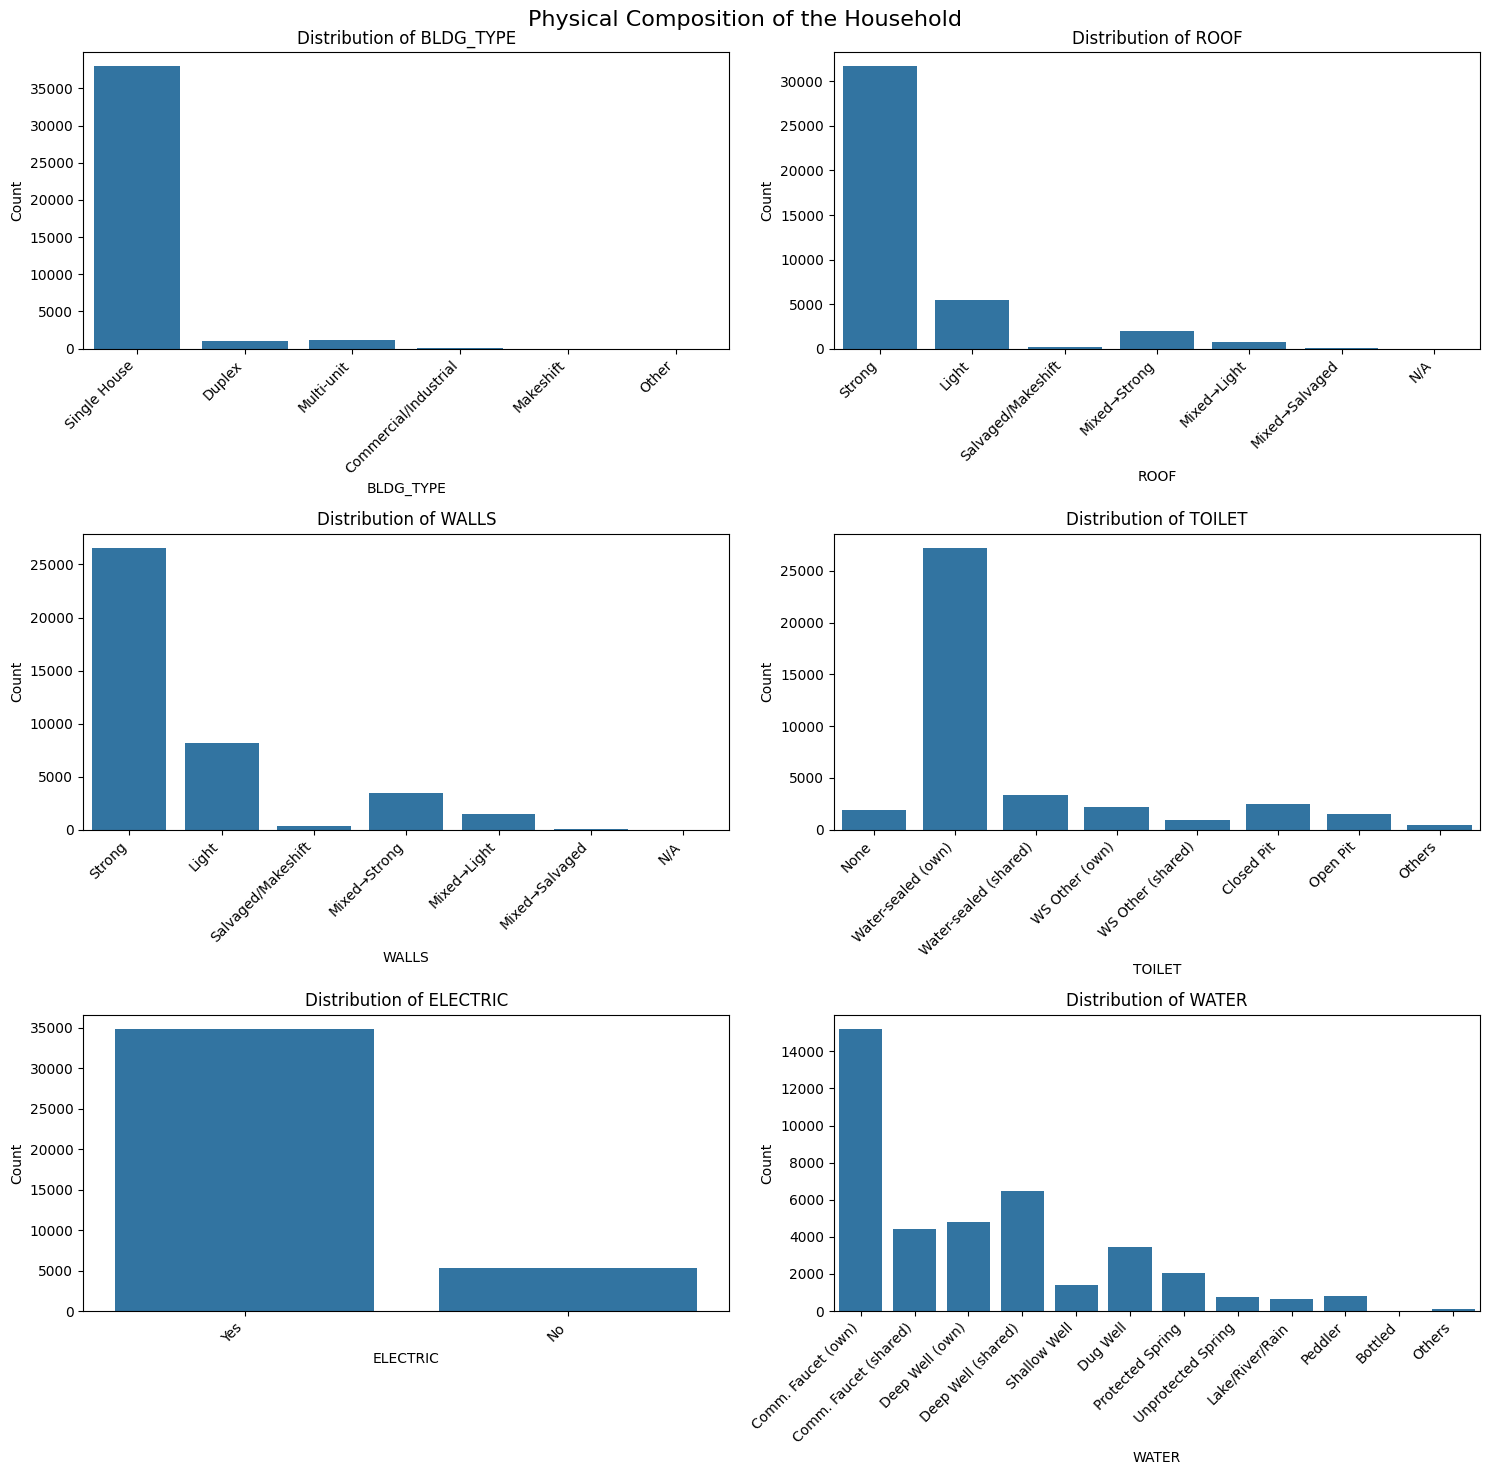

In [64]:
# B. Visualizing Physical Housing Composition (Categorical)
label_map_by_feature = {
    "BLDG_TYPE": BLDG_LABELS,
    "ROOF": ROOF_LABELS,
    "WALLS": WALLS_LABELS,
    "TOILET": TOILET_LABELS,
    "ELECTRIC": ELECTRIC_LABELS,
    "WATER": WATER_LABELS,
}

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle("Physical Composition of the Household", fontsize=16)

for i, col in enumerate(physical_features):
    if col in ws_or_na_df.columns:
        ax = axes[i // 2, i % 2]
        sns.countplot(data=ws_or_na_df, x=col, ax=ax)
        ax.set_title(f"Distribution of {col}")
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylabel("Count")

        if col in label_map_by_feature:
            set_xtick_labels(ax, label_map_by_feature[col])

plt.tight_layout()
plt.show()

These are it's specific measurements

In [67]:
physical_features = ["BLDG_TYPE", "ROOF", "WALLS", "TOILET", "ELECTRIC", "WATER"]

# A. Statistical summaries as one consolidated table
label_map_by_feature = {
    "BLDG_TYPE": BLDG_LABELS,
    "ROOF": ROOF_LABELS,
    "WALLS": WALLS_LABELS,
    "TOILET": TOILET_LABELS,
    "ELECTRIC": ELECTRIC_LABELS,
    "WATER": WATER_LABELS,
}

summary_rows = []
for col in physical_features:
    if col in ws_or_na_df.columns:
        value_pct = ws_or_na_df[col].value_counts(normalize=True, dropna=False) * 100
        label_map = label_map_by_feature.get(col, {})

        for category, pct in value_pct.items():
            if pd.isna(category):
                category_label = "Missing"
                category_code = "NaN"
            else:
                category_label = label_map.get(category, str(category))
                category_code = category

            summary_rows.append(
                {
                    "Feature": col,
                    "Category_Code": category_code,
                    "Category_Label": category_label,
                    "Percentage": pct,
                }
            )

physical_summary_df = pd.DataFrame(summary_rows)
physical_summary_df = physical_summary_df.sort_values(
    ["Feature", "Percentage"],
    ascending=[True, False],
).reset_index(drop=True)

print("Physical Housing Composition Summaries")
display(physical_summary_df.style.format({"Percentage": "{:.2f}%"}))

Physical Housing Composition Summaries


,Feature,Category_Code,Category_Label,Percentage
0,BLDG_TYPE,1,Single House,94.50%
1,BLDG_TYPE,3,Multi-unit,2.96%
2,BLDG_TYPE,2,Duplex,2.39%
3,BLDG_TYPE,4,Commercial/Industrial,0.11%
4,BLDG_TYPE,5,Makeshift,0.03%
5,BLDG_TYPE,6,Other,0.01%
6,ELECTRIC,1,Yes,86.84%
7,ELECTRIC,2,No,13.16%
8,ROOF,1,Strong,78.87%
9,ROOF,2,Light,13.70%


Because our main target is Urban vs Rural classification, we now move from overall summaries to class-separated distributions. This view helps us compare how each category behaves within Urban households versus Rural households, making class-specific patterns easier to interpret.

#### Household Construction

Lets take a look at the class-separated distributions of household construction using the featues `BLDG_TYPE`, `ROOF`, and `WALLS`

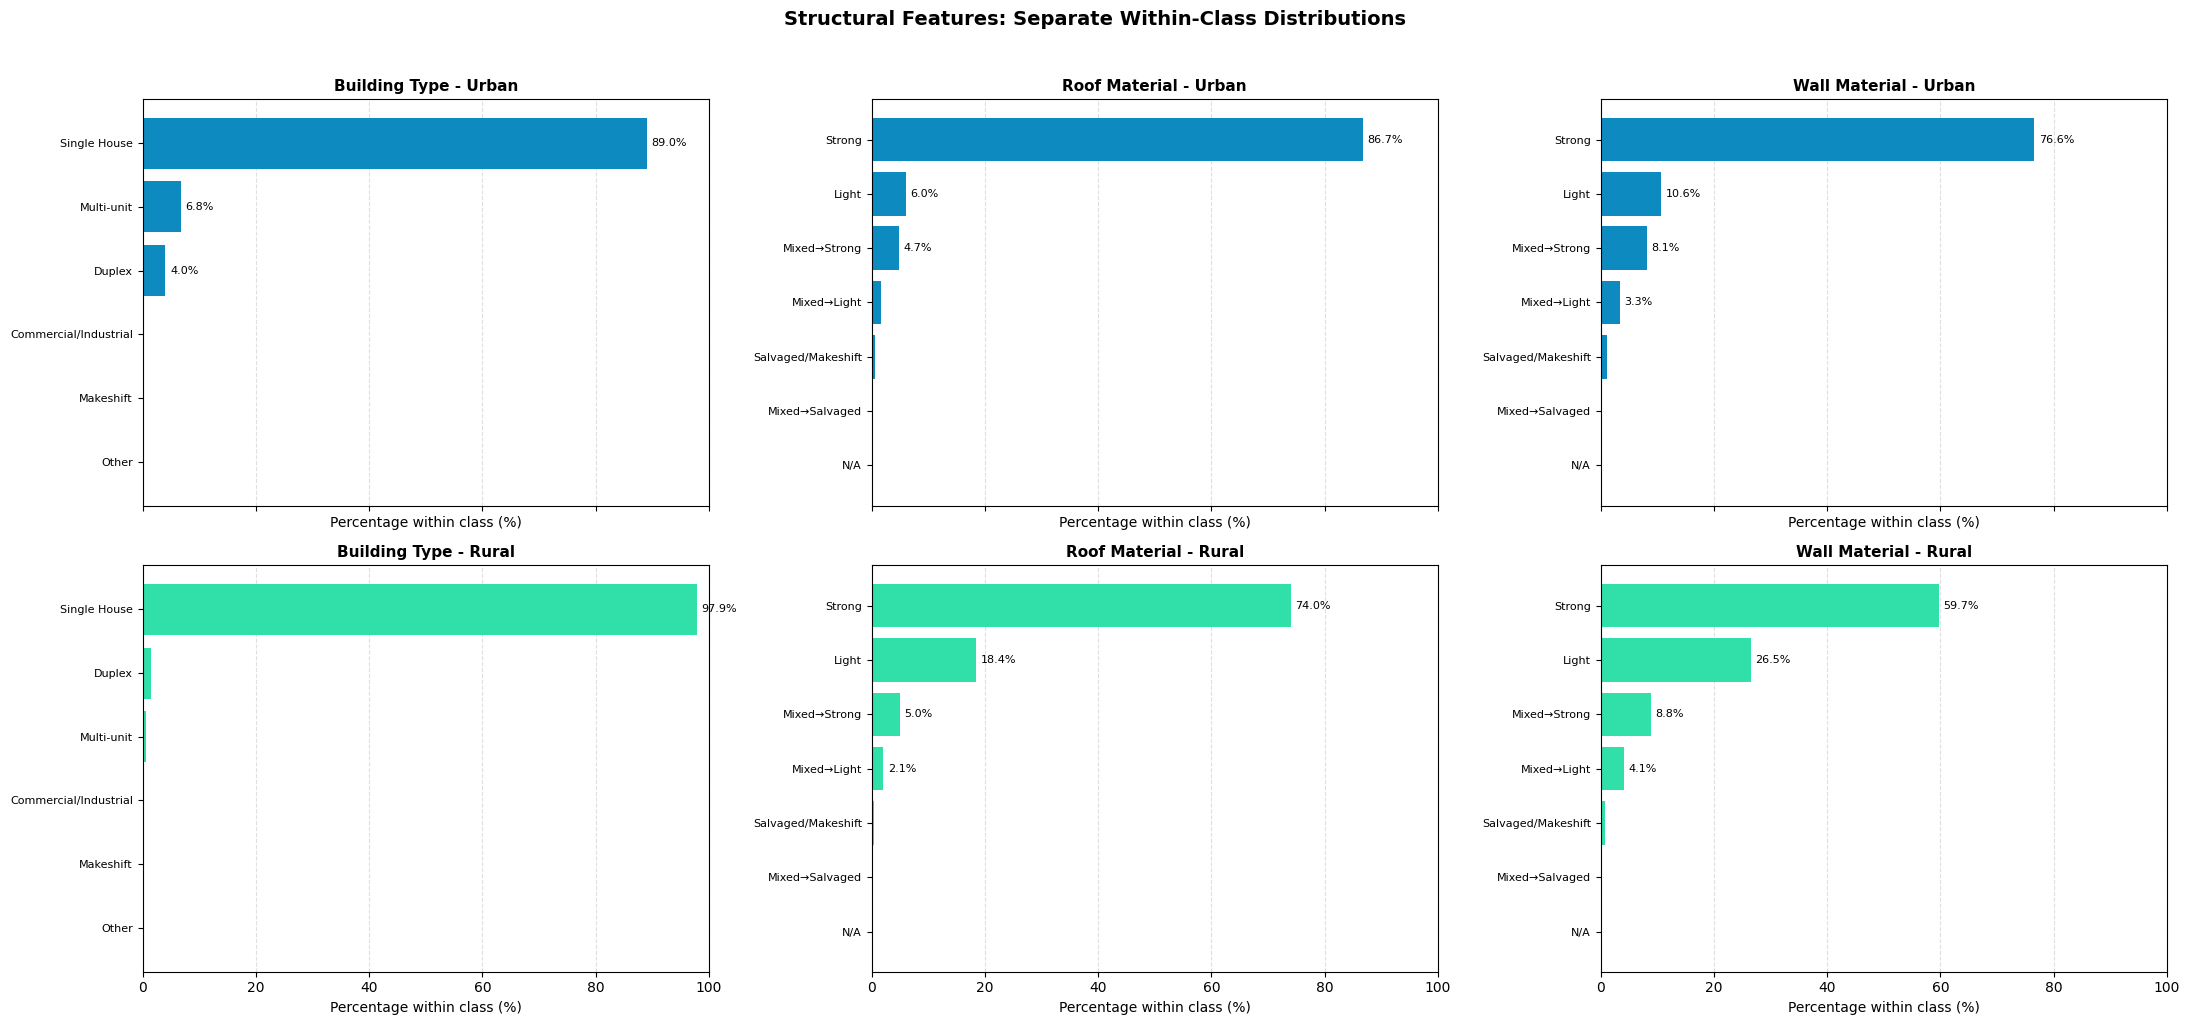

In [62]:
# Use reusable helper from MCO_functions.py for class-separated distributions
features = [
    ("BLDG_TYPE", BLDG_LABELS, "Building Type"),
    ("ROOF", ROOF_LABELS, "Roof Material"),
    ("WALLS", WALLS_LABELS, "Wall Material"),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 10), sharex=True)

for j, (col, label_map, feature_title) in enumerate(features):
    plot_single_class_distribution(
        axes[0, j],
        fies_subset_df_labeled,
        col,
        label_map,
        "Urban",
        urban_c,
        f"{feature_title} - Urban",
    )
    plot_single_class_distribution(
        axes[1, j],
        fies_subset_df_labeled,
        col,
        label_map,
        "Rural",
        rural_c,
        f"{feature_title} - Rural",
    )

fig.suptitle("Structural Features: Separate Within-Class Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### Household Amenities

Next, let's look at `TOILET`, `ELECTRICITY`, and `WATER` distribution of the two classes.

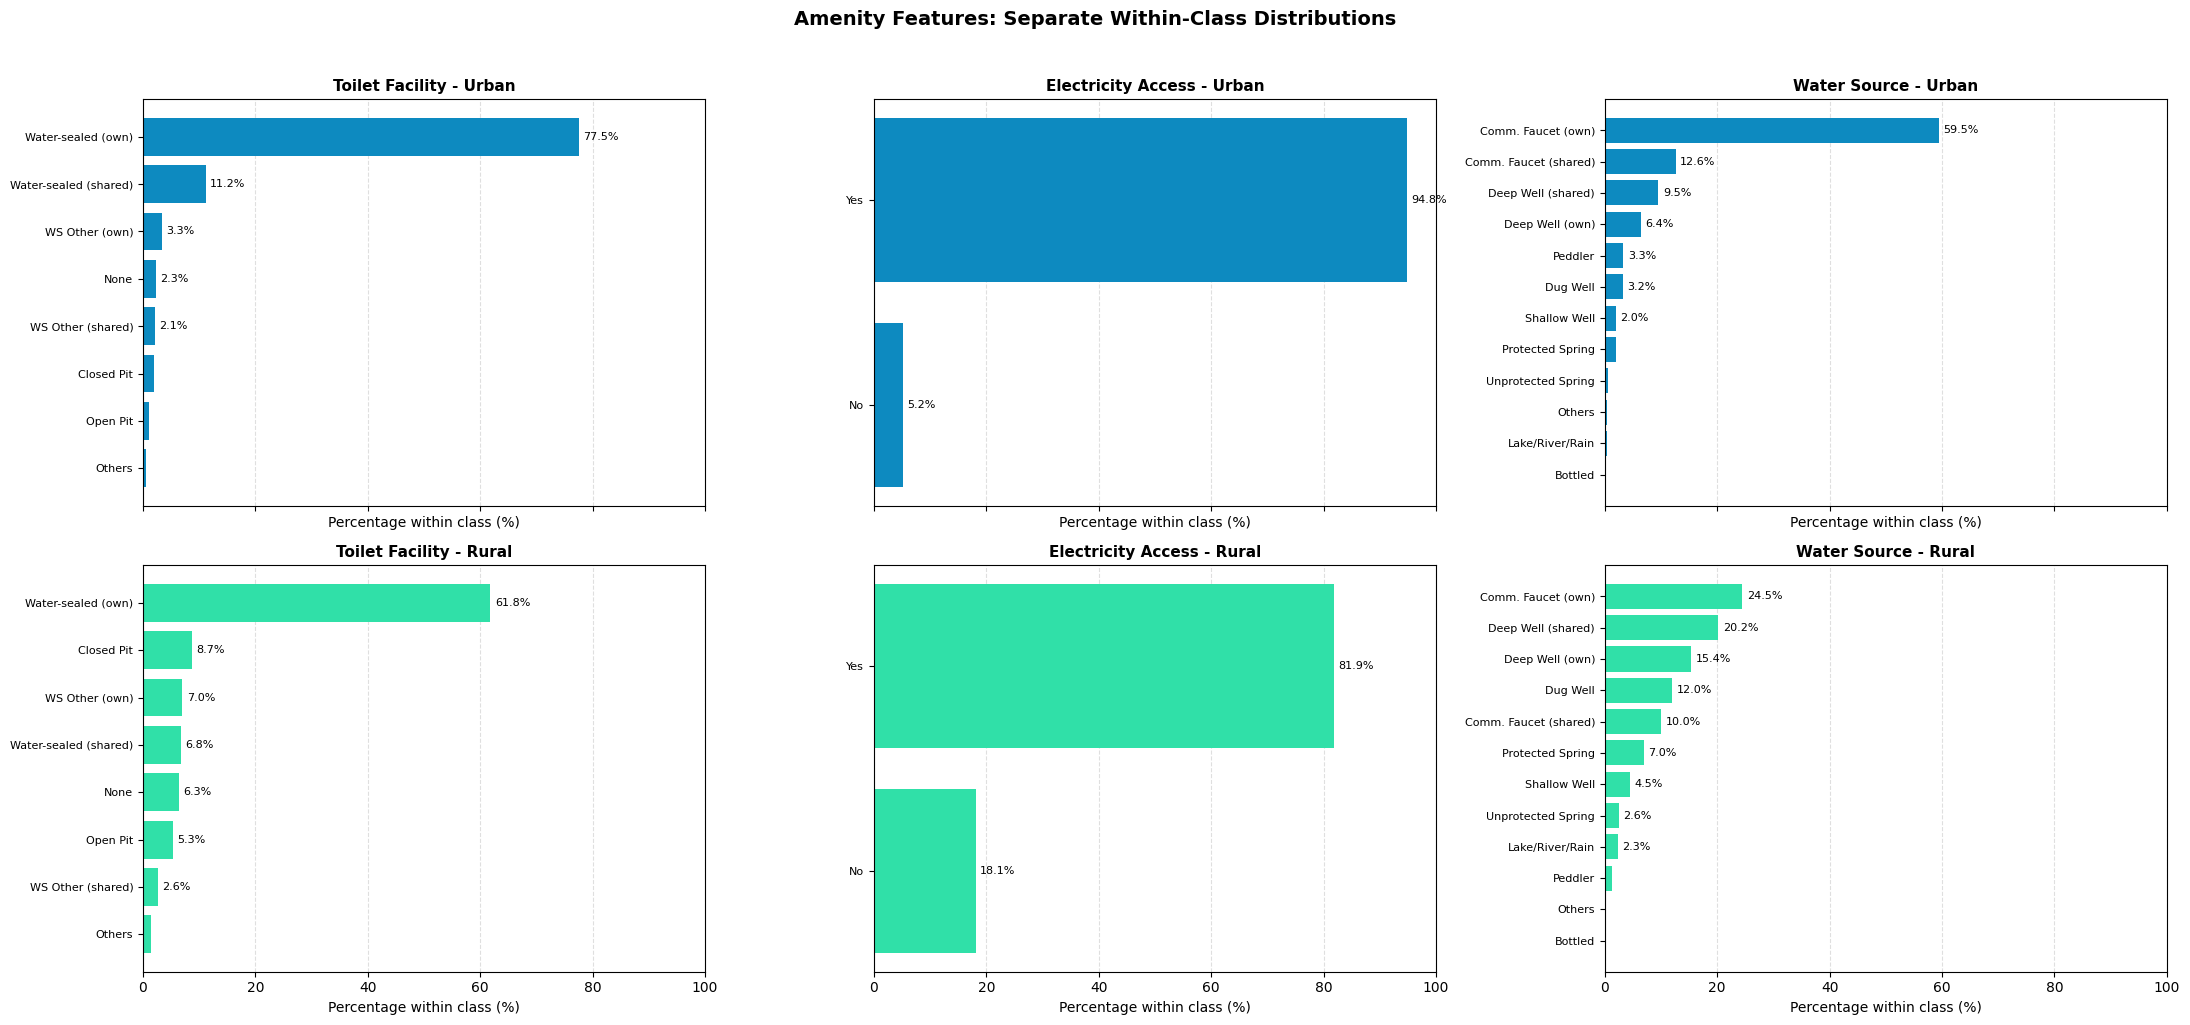

In [63]:
amenity_features = [
    ("TOILET", TOILET_LABELS, "Toilet Facility"),
    ("ELECTRIC", ELECTRIC_LABELS, "Electricity Access"),
    ("WATER", WATER_LABELS, "Water Source"),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 10), sharex=True)

for j, (col, label_map, feature_title) in enumerate(amenity_features):
    plot_single_class_distribution(
        axes[0, j],
        fies_subset_df_labeled,
        col,
        label_map,
        "Urban",
        urban_c,
        f"{feature_title} - Urban",
    )
    plot_single_class_distribution(
        axes[1, j],
        fies_subset_df_labeled,
        col,
        label_map,
        "Rural",
        rural_c,
        f"{feature_title} - Rural",
    )

fig.suptitle("Amenity Features: Separate Within-Class Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### Appliance & Vehicle Ownership: Urban vs Rural
We then compare the average number of household assets and vehicles owned by Urban and Rural families. The chart highlights relative ownership intensity (for example cellphone, TV, refrigerator, motorcycle, and car) and helps identify lifestyle and access differences that may serve as useful predictors for the Urban-Rural classification task.

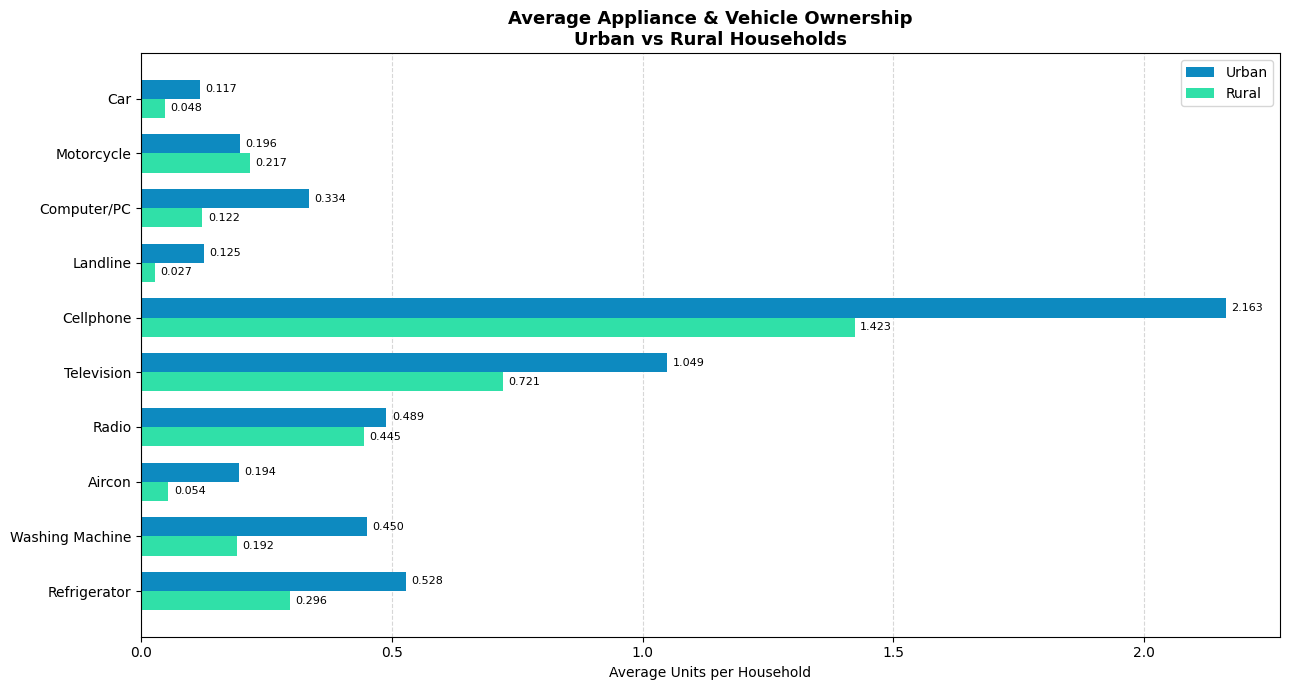

In [16]:

appliance_cols = {
    "CAR_QTY":        "Car",
    "MOTORCYCLE_QTY": "Motorcycle",
    "PC_QTY":         "Computer/PC",
    "LANDLINE_QTY":   "Landline",
    "CELLPHONE_QTY":  "Cellphone",
    "TV_QTY":         "Television",
    "RADIO_QTY":      "Radio",
    "AIRCON_QTY":     "Aircon",
    "WASH_QTY":       "Washing Machine",
    "REF_QTY":        "Refrigerator",
}

app_df = fies_subset_df_labeled[list(appliance_cols.keys()) + ["URB_LABEL"]].copy()
for col in appliance_cols:
    app_df[col] = pd.to_numeric(app_df[col], errors="coerce")

app_mean = (
    app_df
    .groupby("URB_LABEL")[list(appliance_cols.keys())]
    .mean()
    .rename(columns=appliance_cols)
    .T
)

n = len(app_mean)
y = np.arange(n)
bar_h = 0.35

fig, ax = plt.subplots(figsize=(13, 7))
b_u = ax.barh(y - bar_h/2, app_mean["Urban"], height=bar_h, label="Urban", color=urban_c)
b_r = ax.barh(y + bar_h/2, app_mean["Rural"],  height=bar_h, label="Rural",  color=rural_c)

ax.bar_label(b_u, padding=4, fmt="{:.3f}", fontsize=8)
ax.bar_label(b_r, padding=4, fmt="{:.3f}", fontsize=8)

ax.set_yticks(y); ax.set_yticklabels(app_mean.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Average Units per Household")
ax.set_title("Average Appliance & Vehicle Ownership\nUrban vs Rural Households",
             fontsize=13, fontweight="bold")
ax.xaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)
ax.legend()
plt.tight_layout(); plt.show()


#### Household Assets
This section examines ownership patterns of household assets and appliances (for example cars, motorcycles, TV, cellphone, refrigerator, and air conditioner). We summarize their distributions, inspect outliers through boxplots, and analyze pairwise relationships using a correlation heatmap to identify assets that tend to be owned together.

In [19]:
asset_features = ['CAR_QTY', 'MOTORCYCLE_QTY', 'PC_QTY', 'LANDLINE_QTY', 'CELLPHONE_QTY', 
                  'TV_QTY', 'RADIO_QTY', 'AIRCON_QTY', 'WASH_QTY', 'REF_QTY']

# A. Statistical summaries
print("\nHousehold Asset Composition Summaries")
display(ws_or_na_df[asset_features].describe())


Household Asset Composition Summaries


,CAR_QTY,MOTORCYCLE_QTY,PC_QTY,LANDLINE_QTY,CELLPHONE_QTY,TV_QTY,RADIO_QTY,AIRCON_QTY,WASH_QTY,REF_QTY
count,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000,40171.000000
mean,0.074332,0.209081,0.203306,0.064499,1.706082,0.846432,0.461701,0.107764,0.290682,0.384979
std,0.326798,0.487354,0.537806,0.279669,1.543661,0.654158,0.535887,0.410240,0.467002,0.535224
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,6.000000,11.000000,6.000000,5.000000,14.000000,7.000000,5.000000,8.000000,6.000000,5.000000


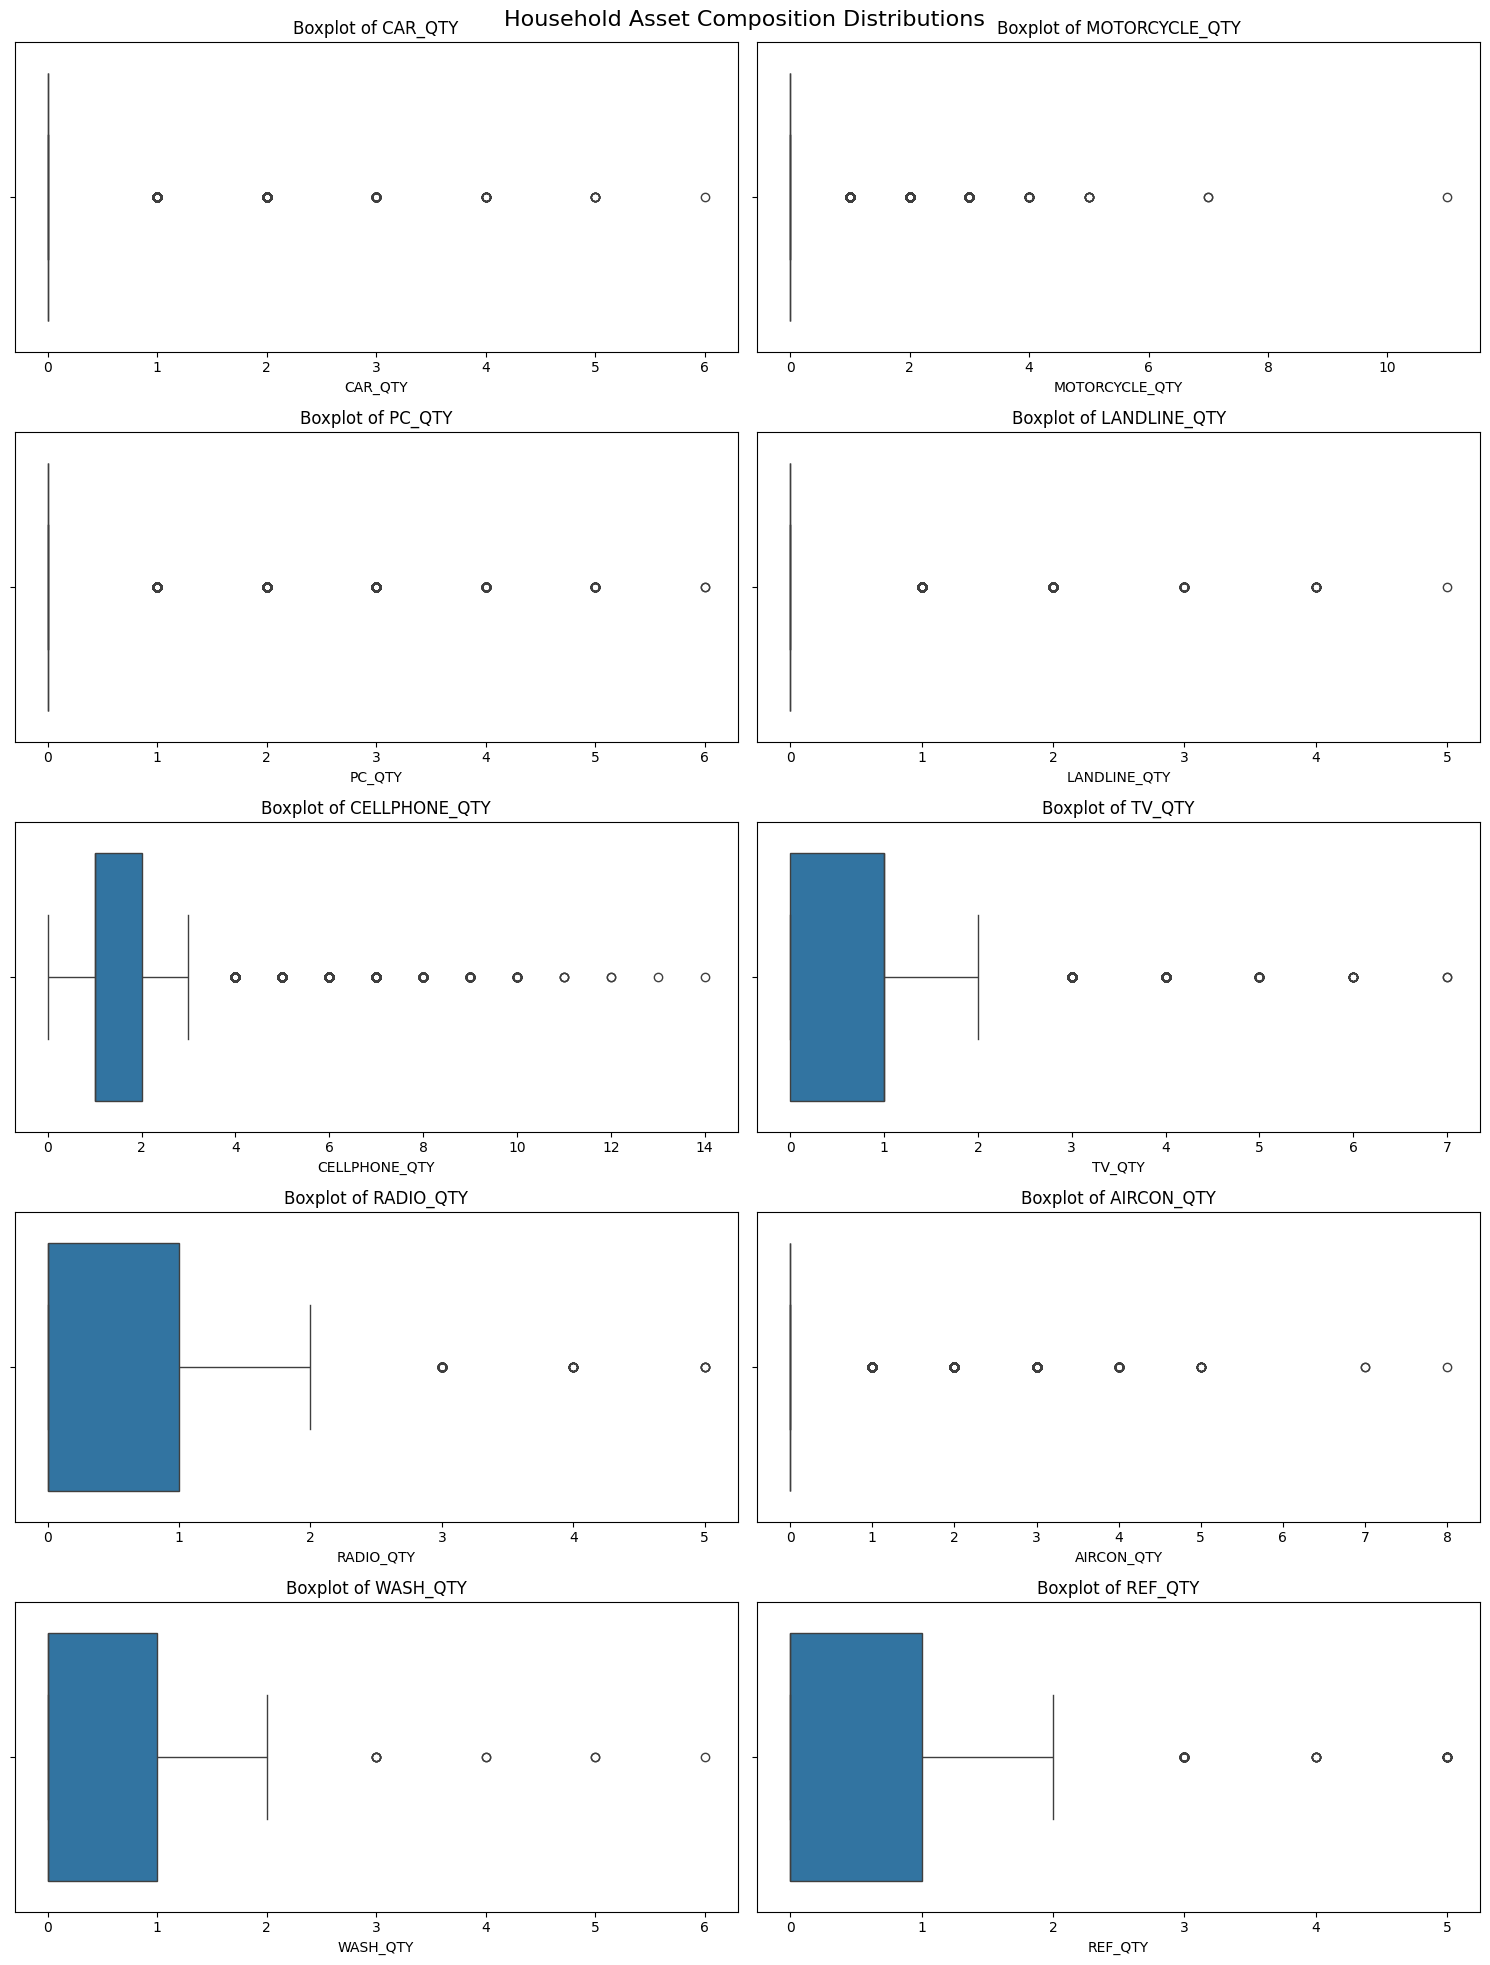

In [20]:
# B. Visualizing Asset/Appliance Quantities (Numerical)
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
fig.suptitle('Household Asset Composition Distributions', fontsize=16)

for i, col in enumerate(asset_features):
    if col in ws_or_na_df.columns:
        ax = axes[i//2, i%2]

        # Using a boxplot to easily spot outliers
        sns.boxplot(data=ws_or_na_df, x=col, ax=ax)
        ax.set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

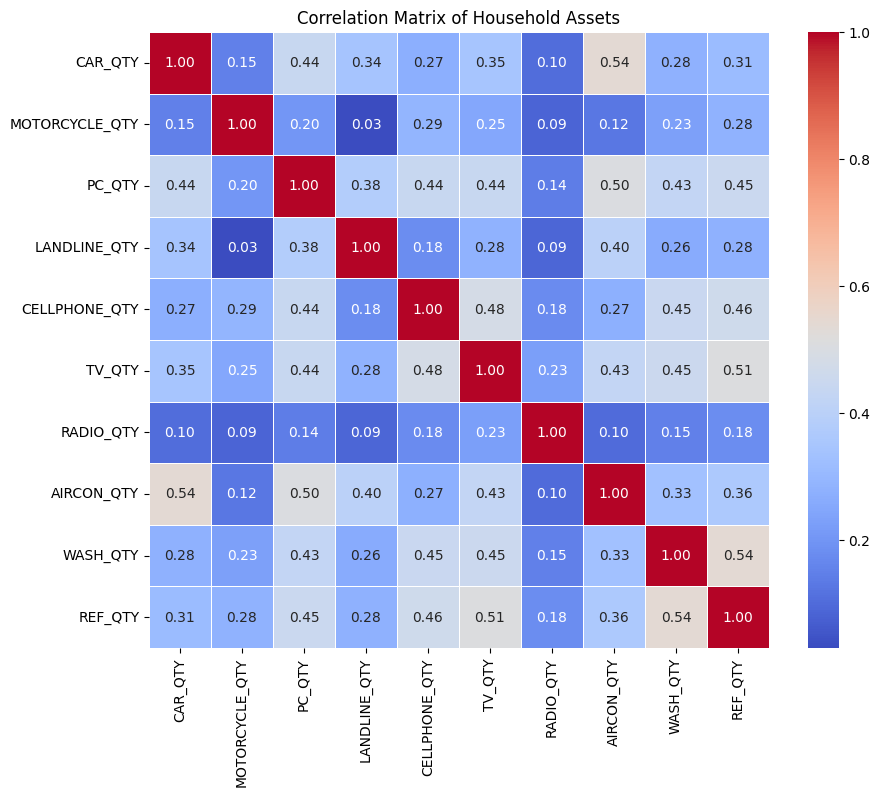

In [21]:
# C. Asset Correlation Heatmap 
# To see if owning certain items correlates with owning others
plt.figure(figsize=(10, 8))

# Coercing errors to NaN due to non-numeric entries (should we move this earlier?)
df_assets_numeric = ws_or_na_df[asset_features].apply(pd.to_numeric, errors='coerce')

correlation_matrix = df_assets_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Household Assets')
plt.show()

# **[3]** Data Preprocessing
In this phase, we will prepare our dataset for the machine learning models. This involves converting our target variable to a standard binary format, testing and handling of outliers, handling nominal categorical variables through One-Hot Encoding, splitting the data into training, validation, and test sets to prevent data leakage, and standardizing our numerical features.

### 1. Target Variable Encoding
Currently, our target variable `URB` is encoded as `1` for Urban and `2` for Rural. Supervised machine learning algorithms generally expect binary classification targets to be represented as `0` and `1`. We will remap the Rural category from `2` to `0`.

In [22]:
# Map URB: 1 remains 1 (Urban), 2 becomes 0 (Rural)
fies_subset_df['URB'] = fies_subset_df['URB'].replace(2, 0)

# Verify the changes
print("Target Variable Distribution (1 = Urban, 0 = Rural):")
print(fies_subset_df['URB'].value_counts())

Target Variable Distribution (1 = Urban, 0 = Rural):
URB
0    24798
1    15373
Name: count, dtype: int64


### 2. Handling Extreme Outliers (Log Transformation)
To determine if our continuous financial features require transformation before modeling, we will visualize the distribution of Total Income (`TOINC`) and Total Expenditures (`T_TOTEX`).

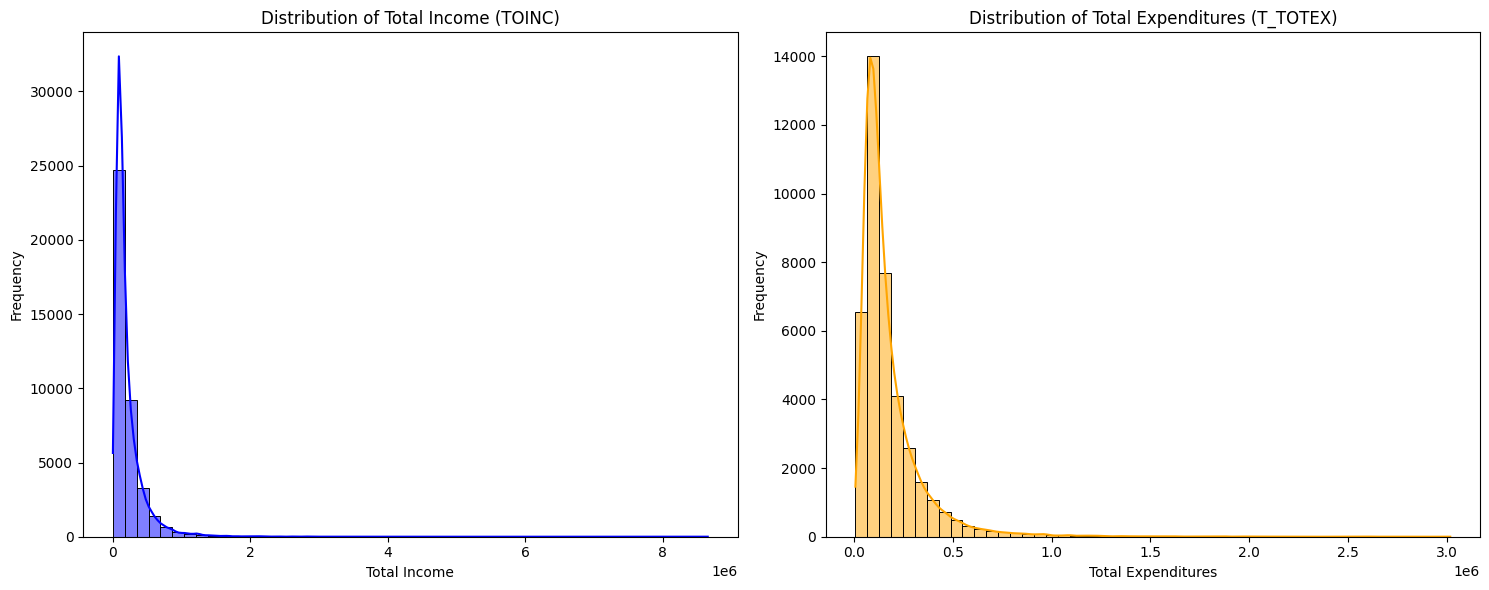

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Total Income
sns.histplot(fies_subset_df['TOINC'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Total Income (TOINC)')
axes[0].set_xlabel('Total Income')
axes[0].set_ylabel('Frequency')

# Plot Total Expenditure
sns.histplot(fies_subset_df['T_TOTEX'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Total Expenditures (T_TOTEX)')
axes[1].set_xlabel('Total Expenditures')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Financial features such as income (`Toinc`) and total expenditures (`T_TOTEX`) are highly right-skewed, meaning a small number of extremely wealthy households act as massive outliers. These extreme values can prevent our classical models and neural networks from learning effectively. 

Instead of dropping these valid data points, we will apply a Logarithmic Transformation (`np.log1p`) to all financial columns. This mathematical transformation pulls extreme values closer to the median, creating a more normalized, "bell-shaped" distribution that machine learning algorithms handle much better. We use `log1p` (which calculates $log(1+x)$) to avoid errors when taking the log of a feature with a value of exactly 0.

In [24]:
# Isolate the financial columns (Income and Expenditures)
# We exclude 'TOILET' just in case the string matcher accidentally catches it
financial_cols = [col for col in fies_subset_df.columns if col.startswith(('T_', 'NET_', 'REGFT', 'EAINC', 'TOINC')) and col != 'TOILET']

# Apply log1p transformation to these specific columns
for col in financial_cols:
    fies_subset_df[col] = np.log1p(fies_subset_df[col])

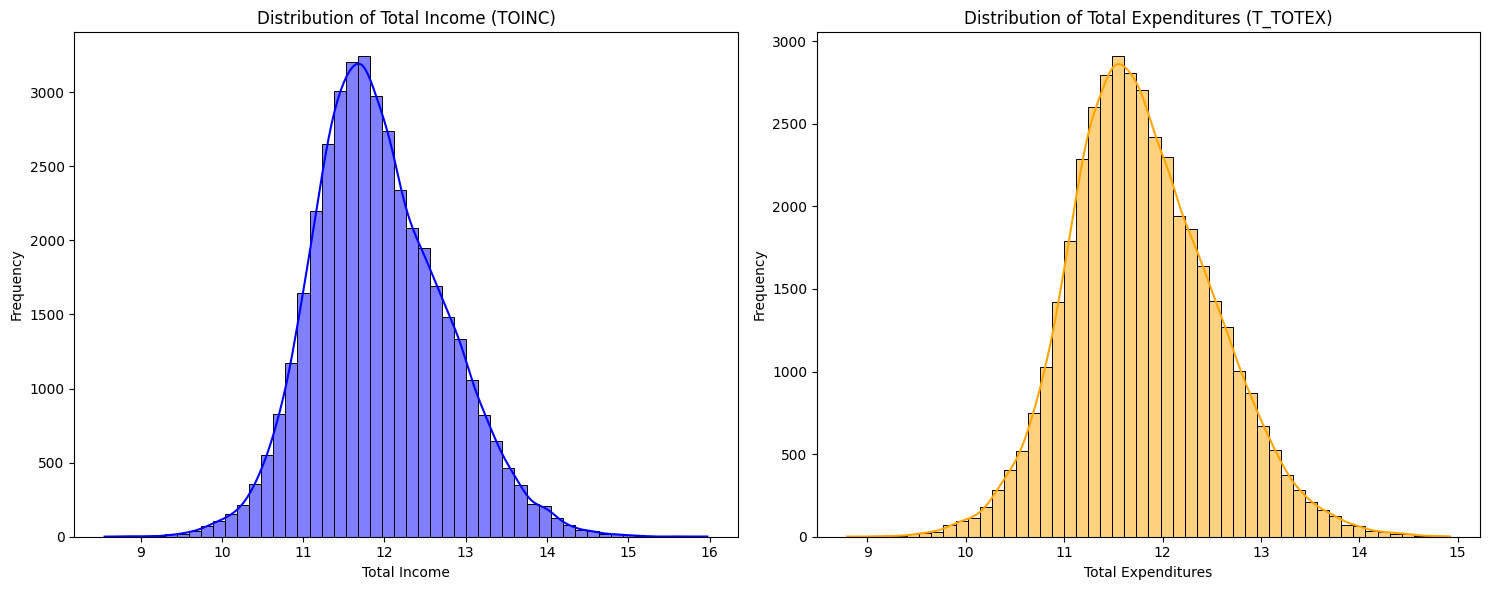

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Total Income
sns.histplot(fies_subset_df['TOINC'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Total Income (TOINC)')
axes[0].set_xlabel('Total Income')
axes[0].set_ylabel('Frequency')

# Plot Total Expenditure
sns.histplot(fies_subset_df['T_TOTEX'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Total Expenditures (T_TOTEX)')
axes[1].set_xlabel('Total Expenditures')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 3. One-Hot Encoding Categorical Features
Our dataset contains several nominal categorical features: `W_REGN`, `BLDG_TYPE`, `ROOF`, `WALLS`, `TOILET`, `ELECTRIC`, and `WATER`. Leaving these as arbitrary numbers might cause algorithms to incorrectly assume they have a mathematical hierarchy (e.g., Region 5 is "greater" than Region 2). 

To fix this, we apply One-Hot Encoding to convert them into binary indicator variables. We also use `drop_first=True` to drop the first category of each feature. This prevents multicollinearity (the "dummy variable trap"), which is highly beneficial for classical machine learning models like Logistic Regression.

In [26]:
# Define categorical columns
categorical_cols = ['W_REGN', 'BLDG_TYPE', 'ROOF', 'WALLS', 'TOILET', 'ELECTRIC', 'WATER']

# Apply One-Hot Encoding
fies_encoded_df = pd.get_dummies(fies_subset_df, columns=categorical_cols, drop_first=True, dtype=int)

# Check the new shape of the dataset
print(f"Original subset shape: {fies_subset_df.shape}")
print(f"Encoded dataset shape: {fies_encoded_df.shape}")

Original subset shape: (40171, 44)
Encoded dataset shape: (40171, 89)


### 4. Train-Validation-Test Split
According to the project specifications, we must ensure proper training-validation-test splits to avoid data leakage. 
* **Training Set (70%):** Used to train our classical models and neural network.
* **Validation Set (15%):** Used to tune hyperparameters and evaluate the models during training.
* **Test Set (15%):** Used for the final, unbiased evaluation of our models.

We will use the `stratify` parameter to ensure the proportion of Urban and Rural households remains perfectly balanced across all three splits.

In [27]:
# Separate Features (X) and Target (y)
X = fies_encoded_df.drop('URB', axis=1)
y = fies_encoded_df['URB']

# First split: 70% Train, 30% Temporary (which will become Val and Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: Divide the 30% Temporary set equally into 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 28119 samples
Validation set: 6026 samples
Testing set: 6026 samples


### 5. Feature Scaling (Using RobustScaler)
Our features operate on vastly different scales. While our financial features have been log-transformed, our asset counts (like `CAR_QTY`) still range from 0 to 5, and our One-Hot Encoded variables are binary (0 or 1). 

Machine learning algorithms—especially Neural Networks and distance-based classical models—require features to be on a similar scale to converge properly. Because we still have some lingering outliers even after the log transformation, we will use `RobustScaler` instead of `StandardScaler`. `RobustScaler` scales the data using the median and the Interquartile Range (IQR), making it completely immune to extreme outliers.

**Important Data Leakage Prevention:** The scaler must be fitted *only* on the training data. We then apply that learned transformation to the validation and test sets.

In [28]:
# Initialize the RobustScaler
scaler = RobustScaler()

# Fit the scaler ONLY on the training data, then transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation and test sets using the previously fitted scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames to retain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Classical ML Model: **Binomial Logistic Regression**


## Model Selection Training


### **Traing Set**: Binomial Logistic Regression

We are trying to predict if the our target class URB is rural or urban, 2 classes so a Binomial Logistic Regression is a natural pick. Let's first create our model using the the import from the sklearn library for our logistic Regression

In [29]:
# Logistic Regression (L2 Regularization) - Training Phase
from sklearn.linear_model import LogisticRegression

# Regularized logistic regression model
logreg_model = LogisticRegression(
    penalty="l2",       # regularization type (this is default)
    C=1.0,               # regularization strength (also a default)
    solver="lbfgs",     # optimizer (good default for larger datasets)
    max_iter=100,
    random_state=42
)

logreg_model.fit(X_train_scaled, y_train)

# Training-set predictions and probabilities
y_train_pred = logreg_model.predict(X_train_scaled)
y_train_proba = logreg_model.predict_proba(X_train_scaled)[:, 1]

With our training split, we currently have **28119** rows. We will use **44** features to predict target feature `URB` whether its rural or urban. But why 88 features? We performed one-hot-encoding on 7 of our used features. `W_REGN`, `BLDG_TYPE`, `ROOF`, `WALLS`, `TOILET`, `ELECTRIC`, and `WATER`. Furthurmore, we remove the target column `URB`.

In [30]:
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Training features used: {X_train_scaled.shape[1]}")

Training samples: 28119
Training features used: 88


Let's now output our metrics. It is important to note that our classes are imbalanced. The entire dataset contains 40171 total number of entries. There are 15373 urban families and 24798 rural families.

In [47]:
from MCO_functions import report_binary_metrics

train_report = report_binary_metrics(
    y_true=y_train,
    y_pred=y_train_pred,
    y_proba=y_train_proba,
    title="Training Metrics",
    n_iter=logreg_model.n_iter_,
)

cm_train = train_report["cm"]
cm_train_df = train_report["cm_df"]
rural_acc_train = train_report["rural_acc"]
urban_acc_train = train_report["urban_acc"]

Training Metrics (Overall)
Accuracy        : 0.8262
Balanced Acc    : 0.8028
ROC-AUC         : 0.8895
PR-AUC          : 0.8628
Log Loss        : 0.3902

Per-Class Metrics


,Rural (0),Urban (1)
Accuracy,0.9024,0.7032
Precision,0.8306,0.8171
Recall,0.9024,0.7032
F1-score,0.8650,0.7559



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)           15664            1694
Actual Urban (1)            3194            7567

Iterations used: [96]


Our model used 96 iterations in the training set, lets visualize a graph of its loss to see how it improves

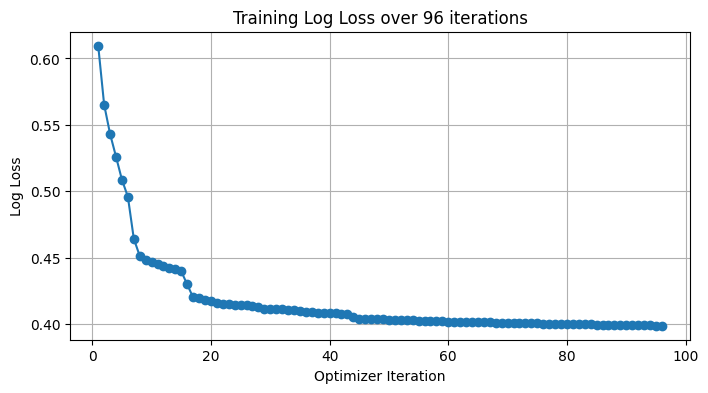

Showing first 10 and last 10 iterations out of 96 total:


,Optimizer Iteration,Train Log Loss
0,1,0.609578
1,2,0.565195
2,3,0.543191
3,4,0.526038
4,5,0.508636
5,6,0.495898
6,7,0.464254
7,8,0.451284
8,9,0.448489
9,10,0.446534


In [41]:
# Optional: inspect training loss over all optimizer iterations (reusable helper)
from MCO_functions import track_logreg_loss_by_iteration

# Track the same number of iterations used by the fitted training model
total_iters = int(np.ravel(logreg_model.n_iter_)[0])

loss_tracking = track_logreg_loss_by_iteration(
    X_train=X_train_scaled,
    y_train=y_train,
    total_iterations=total_iters,
    c=1.0,
    penalty="l2",
    solver="lbfgs",
    class_weight=None,
    random_state=42,
    head_n=10,
    tail_n=10,
    plot=True,
)

loss_history_df = loss_tracking["full_loss_df"]
loss_window_df = loss_tracking["compact_loss_df"]

print(f"Showing first 10 and last 10 iterations out of {total_iters} total:")
display(loss_window_df.style.format({"Train Log Loss": "{:.6f}"}))

## Error Analysis and Model Tuning


### **Validation Set** (Pre-Tuned): Binomial Logistic Regression

Using our trained model, let's test it on the validation set. The validation set has **6026** rows of data

In [ ]:
from MCO_functions import report_binary_metrics

# BEFORE TUNING: baseline validation metrics
y_val_pred = logreg_model.predict(X_val_scaled)
y_val_proba = logreg_model.predict_proba(X_val_scaled)[:, 1]

val_base_report = report_binary_metrics(
    y_true=y_val,
    y_pred=y_val_pred,
    y_proba=y_val_proba,
    title="Current Validation Metrics (Before Tuning)",
)

cm_base = val_base_report["cm"]
cm_base_df = val_base_report["cm_df"]
rural_acc_base = val_base_report["rural_acc"]
urban_acc_base = val_base_report["urban_acc"]

Current Validation Metrics (Before Tuning) (Overall)
Accuracy        : 0.8140
Balanced Acc    : 0.7925
ROC-AUC         : 0.8793
PR-AUC          : 0.8498
Log Loss        : 0.4072

Per-Class Metrics


,Rural (0),Urban (1)
Accuracy,0.8839,0.7012
Precision,0.8268,0.7892
Recall,0.8839,0.7012
F1-score,0.8544,0.7426



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3288             432
Actual Urban (1)             689            1617


Let's compare the model's performance with the training and validation set.

In [46]:
# Training vs Pre-Tuned Validation comparison with color highlights
metric_order = [
    "Accuracy", "Balanced Acc", "Rural Accuracy", "Urban Accuracy",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map = {
    "Accuracy": "higher", "Balanced Acc": "higher", "Rural Accuracy": "higher",
    "Urban Accuracy": "higher", "ROC-AUC": "higher", "PR-AUC": "higher",
    "Log Loss": "lower",
}

comparison_df = pd.concat(
    [
        build_metric_series(y_train, y_train_pred, y_train_proba, cm_train, metric_order).rename("Training"),
        build_metric_series(y_val, y_val_pred, y_val_proba, cm_base, metric_order).rename("Pre-Tuned Validation"),
    ],
    axis=1,
)
comparison_df["Val - Train"] = comparison_df["Pre-Tuned Validation"] - comparison_df["Training"]

styled_comparison = (
    comparison_df.style
    .format(
        {
            "Training": "{:.4f}",
            "Pre-Tuned Validation": "{:.4f}",
            "Val - Train": "{:+.4f}",
        }
    )
    .apply(lambda row: highlight_val_train_row(row, direction_map, delta_col="Val - Train"), axis=1)
    .set_caption(
        "Training vs Pre-Tuned Validation Metrics "
        "(Val - Train color: green = better on validation given metric direction, red = worse, yellow = tie)"
    )
)

#### Validation set vs Training set

The behaviour is expected. Since the model still hasn't seen the validation set, a lower overall perfomance is expected.

In [35]:
print("Training vs Pre-Tuned Validation")
print("Legend: Green = improved on validation, Red = dropped on validation, Yellow = no change")
display(styled_comparison)

Training vs Pre-Tuned Validation
Legend: Green = improved on validation, Red = dropped on validation, Yellow = no change


,Training,Pre-Tuned Validation,Val - Train
Accuracy,0.8262,0.8140,-0.0122
Balanced Acc,0.8028,0.7925,-0.0103
Rural Accuracy,0.9024,0.8839,-0.0185
Urban Accuracy,0.7032,0.7012,-0.0020
ROC-AUC,0.8895,0.8793,-0.0102
PR-AUC,0.8628,0.8498,-0.0130
Log Loss,0.3902,0.4072,+0.0171


With that in mind, let's **fine-tune** our model

We will create a list of values per hyperparameters located in `run_logreg_validation_grid` function. The function iterates through the possible combinations/configurations of hyperparameters and chooses the best set of hyperparameters

We base our decision of the best (highest) `balanced accuracy` because of our high class imbalance, **38% Urban** and **61% Rural**.

### **Validation Set** (Tuned): Biomial Logistic Regression 

In [ ]:
# Fine tuning our model with validation set
candidate_df = run_logreg_validation_grid(X_train_scaled, y_train, X_val_scaled, y_val)

print("\nValidation Tuning Results (top 5):")
display(candidate_df.head(5))

best = candidate_df.iloc[0]
best_c = float(best["C"])
best_solver = str(best["Solver"])
best_threshold = float(best["Threshold"])

if best["Class_Weight"] == "None":
    best_class_weight = None
elif best["Class_Weight"] == "balanced":
    best_class_weight = "balanced"
else:
    best_class_weight = ast.literal_eval(best["Class_Weight"])

print("\nBest validation configuration (Balanced):")
print(f"C            : {best_c}")
print(f"Solver       : {best_solver}")
print(f"Class Weight : {best_class_weight}")
print(f"Threshold    : {best_threshold}")

# Fit tuned model selected from validation ranking
logreg_model_tuned = LogisticRegression(
    penalty="l2",
    C=best_c,
    solver=best_solver,
    class_weight=best_class_weight,
    max_iter=1000,
    random_state=42
)
logreg_model_tuned.fit(X_train_scaled, y_train)

y_val_proba_tuned = logreg_model_tuned.predict_proba(X_val_scaled)[:, 1]
y_val_pred_tuned = (y_val_proba_tuned >= best_threshold).astype(int)


Validation Tuning Results (top 5):


,C,Solver,Class_Weight,Threshold,Accuracy,Balanced_Acc,Rural_Acc,Urban_Acc,Rural_Precision,Rural_Recall,Rural_F1,Urban_Precision,Urban_Recall,Urban_F1,ROC_AUC,PR_AUC,LogLoss
0,3.0,lbfgs,"{0: 1.1, 1: 1.0}",0.35,0.806505,0.802401,0.819892,0.784909,0.860124,0.819892,0.839527,0.729839,0.784909,0.756373,0.879236,0.849980,0.407386
1,30.0,liblinear,"{0: 1.15, 1: 1.0}",0.34,0.806173,0.802297,0.818817,0.785776,0.860452,0.818817,0.839118,0.728882,0.785776,0.756260,0.879077,0.850058,0.408014
2,3.0,lbfgs,"{0: 1.15, 1: 1.0}",0.34,0.806173,0.802214,0.819086,0.785343,0.860248,0.819086,0.839163,0.729066,0.785343,0.756159,0.879138,0.849959,0.407948
3,3.0,lbfgs,"{0: 1.2, 1: 1.0}",0.33,0.806173,0.802214,0.819086,0.785343,0.860248,0.819086,0.839163,0.729066,0.785343,0.756159,0.879132,0.850031,0.408624
4,10.0,lbfgs,"{0: 1.15, 1: 1.0}",0.34,0.806173,0.802214,0.819086,0.785343,0.860248,0.819086,0.839163,0.729066,0.785343,0.756159,0.879101,0.849978,0.408025



Best validation configuration (Balanced):
C            : 3.0
Solver       : lbfgs
Class Weight : {0: 1.1, 1: 1.0}
Threshold    : 0.35


In [45]:
from MCO_functions import report_binary_metrics

val_tuned_report = report_binary_metrics(
    y_true=y_val,
    y_pred=y_val_pred_tuned,
    y_proba=y_val_proba_tuned,
    title="Tuned Model Validation Metrics",
    threshold=best_threshold,
    n_iter=logreg_model_tuned.n_iter_,
)

cm_tuned = val_tuned_report["cm"]
cm_tuned_df = val_tuned_report["cm_df"]
rural_acc_tuned = val_tuned_report["rural_acc"]
urban_acc_tuned = val_tuned_report["urban_acc"]



Tuned Model Validation Metrics (Overall)
Threshold used  : 0.35
Accuracy        : 0.8065
Balanced Acc    : 0.8024
ROC-AUC         : 0.8792
PR-AUC          : 0.8500
Log Loss        : 0.4074

Per-Class Metrics


,Rural (0),Urban (1)
Accuracy,0.8199,0.7849
Precision,0.8601,0.7298
Recall,0.8199,0.7849
F1-score,0.8395,0.7564



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3050             670
Actual Urban (1)             496            1810

Iterations used: [92]


What hyperparameters changed during tuning?

In [44]:
print("\nWhat changed during tuning?")
print(f"- C: 1.0 -> {best_c}")
print(f"- Solver: lbfgs -> {best_solver}")
print(f"- Class weight: None -> {best_class_weight}")
print(f"- Decision threshold: 0.50 -> {best_threshold}")


What changed during tuning?
- C: 1.0 -> 3.0
- Solver: lbfgs -> lbfgs
- Class weight: None -> {0: 1.1, 1: 1.0}
- Decision threshold: 0.50 -> 0.35


Now let's check if the model's performance post-tuning improved againts pre-tuning

In [68]:
# Pre-tuned vs Post-tuned validation comparison (same style as earlier comparison table)
metric_order_tuning = [
    "Accuracy", "Balanced Acc", "Rural Accuracy", "Urban Accuracy",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map_tuning = {
    "Accuracy": "higher",
    "Balanced Acc": "higher",
    "Rural Accuracy": "higher",
    "Urban Accuracy": "higher",
    "ROC-AUC": "higher",
    "PR-AUC": "higher",
    "Log Loss": "lower",
}

tuned_comparison_df = pd.concat(
    [
        build_metric_series(y_val, y_val_pred, y_val_proba, cm_base, metric_order_tuning).rename("Pre-Tuned Validation"),
        build_metric_series(y_val, y_val_pred_tuned, y_val_proba_tuned, cm_tuned, metric_order_tuning).rename("Post-Tuned Validation"),
    ],
    axis=1,
)
tuned_comparison_df["Post - Pre"] = (
    tuned_comparison_df["Post-Tuned Validation"] - tuned_comparison_df["Pre-Tuned Validation"]
)

styled_tuned_comparison = (
    tuned_comparison_df.style
    .format(
        {
            "Pre-Tuned Validation": "{:.4f}",
            "Post-Tuned Validation": "{:.4f}",
            "Post - Pre": "{:+.4f}",
        }
    )
    .apply(
        lambda row: highlight_val_train_row(row, direction_map_tuning, delta_col="Post - Pre"),
        axis=1,
    )
    .set_caption(
        "Pre-Tuned vs Post-Tuned Validation Metrics "
        "(Post - Pre color: green = improved after tuning given metric direction, red = worse, yellow = tie)"
    )
)

print("Pre-Tuned vs Post-Tuned Validation")
print("Legend: Green = improved after tuning, Red = dropped after tuning, Yellow = no change")
display(styled_tuned_comparison)

Pre-Tuned vs Post-Tuned Validation
Legend: Green = improved after tuning, Red = dropped after tuning, Yellow = no change


,Pre-Tuned Validation,Post-Tuned Validation,Post - Pre
Accuracy,0.8140,0.8065,-0.0075
Balanced Acc,0.7925,0.8024,+0.0099
Rural Accuracy,0.8839,0.8199,-0.0640
Urban Accuracy,0.7012,0.7849,+0.0837
ROC-AUC,0.8793,0.8792,-0.0001
PR-AUC,0.8498,0.8500,+0.0002
Log Loss,0.4072,0.4074,+0.0001


## Model Evaluation


### **Test Set**: Binomial Logistic Regression

The test split also contains **6026** entries of data.

In [38]:
from MCO_functions import report_binary_metrics

# Final Test-Set Evaluation (locked model from validation tuning)
# Use tuned model and tuned decision threshold selected on validation set
y_test_proba = logreg_model_tuned.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

test_report = report_binary_metrics(
    y_true=y_test,
    y_pred=y_test_pred,
    y_proba=y_test_proba,
    title="Final Test Metrics",
    threshold=best_threshold,
)

cm_test = test_report["cm"]
cm_test_df = test_report["cm_df"]
rural_acc_test = test_report["rural_acc"]
urban_acc_test = test_report["urban_acc"]

Final Test Metrics (Overall)
Threshold used  : 0.35
Accuracy        : 0.8050
Balanced Acc    : 0.7998
ROC-AUC         : 0.8852
PR-AUC          : 0.8575
Log Loss        : 0.3975
Recall Gap      : 0.0445

Per-Class Metrics


,Rural (0),Urban (1)
Accuracy,0.8220,0.7775
Precision,0.8563,0.7303
Recall,0.8220,0.7775
F1-score,0.8388,0.7532



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3058             662
Actual Urban (1)             513            1793


Now let's compare the model's performance on the test and post-tuning sets

In [69]:
# Post-tuned validation vs Test-set comparison (same style as earlier comparison table)
metric_order_test = [
    "Accuracy", "Balanced Acc", "Rural Accuracy", "Urban Accuracy",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map_test = {
    "Accuracy": "higher",
    "Balanced Acc": "higher",
    "Rural Accuracy": "higher",
    "Urban Accuracy": "higher",
    "ROC-AUC": "higher",
    "PR-AUC": "higher",
    "Log Loss": "lower",
}

test_comparison_df = pd.concat(
    [
        build_metric_series(y_val, y_val_pred_tuned, y_val_proba_tuned, cm_tuned, metric_order_test).rename("Post-Tuned Validation"),
        build_metric_series(y_test, y_test_pred, y_test_proba, cm_test, metric_order_test).rename("Test Set"),
    ],
    axis=1,
)
test_comparison_df["Test - Post"] = (
    test_comparison_df["Test Set"] - test_comparison_df["Post-Tuned Validation"]
)

styled_test_comparison = (
    test_comparison_df.style
    .format(
        {
            "Post-Tuned Validation": "{:.4f}",
            "Test Set": "{:.4f}",
            "Test - Post": "{:+.4f}",
        }
    )
    .apply(
        lambda row: highlight_val_train_row(row, direction_map_test, delta_col="Test - Post"),
        axis=1,
    )
    .set_caption(
        "Post-Tuned Validation vs Test-Set Metrics "
        "(Test - Post color: green = improved on test given metric direction, red = worse, yellow = tie)"
    )
)

print("Post-Tuned Validation vs Test Set")
print("Legend: Green = improved on test set, Red = dropped on test set, Yellow = no change")
display(styled_test_comparison)

Post-Tuned Validation vs Test Set
Legend: Green = improved on test set, Red = dropped on test set, Yellow = no change


,Post-Tuned Validation,Test Set,Test - Post
Accuracy,0.8065,0.8050,-0.0015
Balanced Acc,0.8024,0.7998,-0.0026
Rural Accuracy,0.8199,0.8220,+0.0022
Urban Accuracy,0.7849,0.7775,-0.0074
ROC-AUC,0.8792,0.8852,+0.0060
PR-AUC,0.8500,0.8575,+0.0075
Log Loss,0.4074,0.3975,-0.0099


## Classical machine learning model #2

## Classical machine learning model #3

## Neural Network model #1

## Neural Network model #1

<hr/>

# AI Declaration
Chavez, Allen Visagar
- sample text

Llanes, Andre Gabriel De Ocampo
- sample text

Rojo, Von Matthew De Guzman *(leader)*
- Uses Google-search that has AI features in synthesizing different sources relevant to questions I asked.
- Uses Google Gemini to ask ways on how to import CSV dataset and scaffolding ideas for EDA

Tan, Jeremy James Teves
- sample text